 Part I - Heatmap full heatmap - base for the animation

In [1]:
# Cell 1: Install required libraries (No bitsandbytes required for unquantized)
!pip install transformers matplotlib seaborn torch accelerate

In [2]:
# Cell 2
! pip install git+https://github.com/huggingface/transformers.git --upgrade

  Cloning https://github.com/huggingface/transformers.git to /tmp/pip-req-build-636zt0zs
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/transformers.git /tmp/pip-req-build-636zt0zs
  Resolved https://github.com/huggingface/transformers.git to commit a29df2d916e3b820aecd19d3b5a877abc523ba3c
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for transformers: filename=transformers-5.6.0.dev0-py3-none-any.whl size=11447989 sha256=70df4297295c5d45d495f55506c6bd4e61dd086223979214aa224f1276b9e0b5
  Stored in directory: /tmp/pip-ephem-wheel-cache-6426xar1/wheels/54/cb/3f/83103de5575c534436d6a4686686dead458238dfaf1147e98d
Successfully built transformers
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [3]:
# Cell 3: Load model
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

model_name = "Qwen/Qwen3.5-4B"
print(f"Loading {model_name}...")

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)

# Load model in standard precision (no 4-bit quantization)
# torch_dtype=torch.bfloat16 or float16 is recommended to avoid OOM errors
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    output_attentions=True,
    trust_remote_code=True,
    device_map="auto",
    torch_dtype=torch.bfloat16
)

Loading Qwen/Qwen3.5-4B...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/12.8M [00:00<?, ?B/s]

...

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/426 [00:00<?, ?it/s]

In [4]:
# Cell 4
# Define input query
query = "What is it like to be a bat?"
inputs = tokenizer(query, return_tensors='pt').to(model.device)

# Process query and extract attention weights
print("Processing input and extracting attention weights...")
with torch.no_grad():
    outputs = model(**inputs)
    attentions = outputs.attentions  # List of tensors (one per layer)

# Get token labels for visualization
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

Processing input and extracting attention weights...


Error: 'attentions' is None. Re-running inference with explicit output_attentions=True...
Generating detailed visualization...


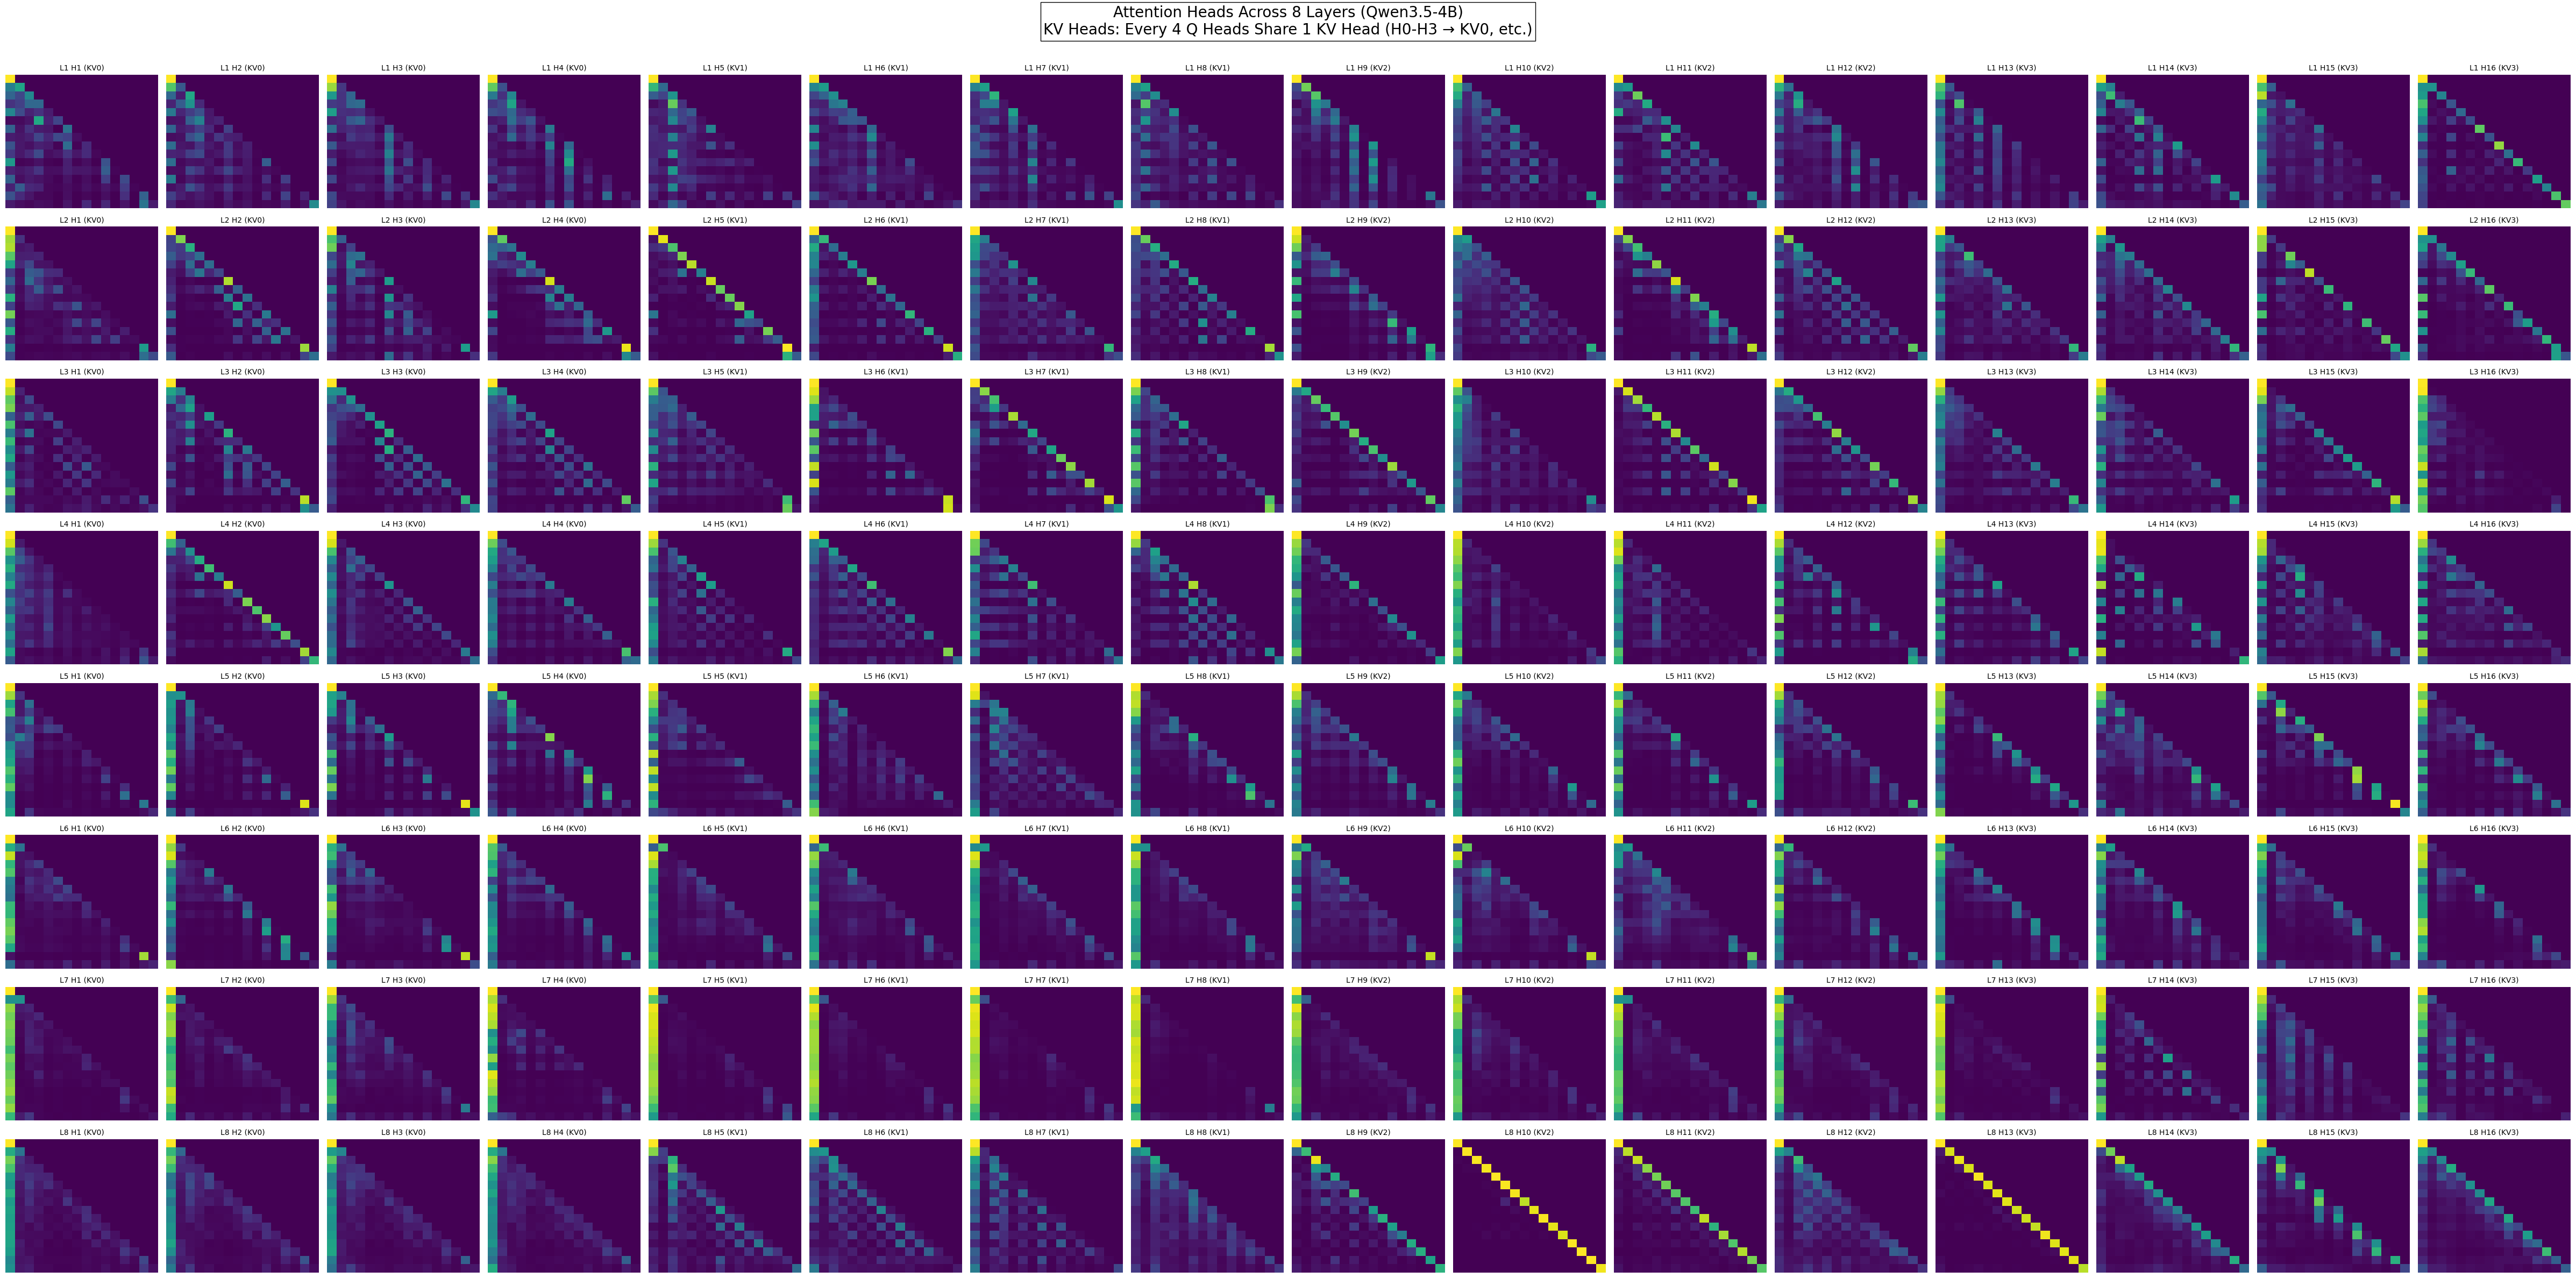

Visualization saved as 'qwen3.5_attention_detailed.png'
File successfully generated.


In [5]:
# Cell 5: Visualization of Attention Heads
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import os

def visualize_all_heads_detailed(tokens, attentions):
    if attentions is None:
        print("Error: 'attentions' is None. Re-running inference with explicit output_attentions=True...")
        # Ensure we use the correct inputs from the previous cell
        inputs = tokenizer(" ".join(tokens).replace("Ġ", " "), return_tensors='pt').to(model.device)
        with torch.no_grad():
            outputs = model(**inputs, output_attentions=True)
            attentions = outputs.attentions

    if attentions is None:
        print("Critical Error: Could not extract attentions. Check if the model supports output_attentions.")
        return

    print("Generating detailed visualization...")

    # Dynamically extract layers and heads
    num_layers = len(attentions)
    num_heads = attentions[0].shape[1]

    # Qwen3.5-4B GQA: 16 Q heads / 4 KV heads = 4 Q heads per KV head
    q_per_kv = 4

    # Create a grid
    fig, axes = plt.subplots(num_layers, num_heads, figsize=(num_heads * 3, num_layers * 3), facecolor='none')

    title_text = (
        f'Attention Heads Across {num_layers} Layers (Qwen3.5-4B)\n'
        f'KV Heads: Every {q_per_kv} Q Heads Share 1 KV Head (H0-H3 → KV0, etc.)'
    )

    fig.suptitle(title_text, fontsize=20, y=0.998, bbox=dict(facecolor='none'))

    for layer_idx, attention_layer in enumerate(attentions):
        for head_idx in range(num_heads):
            # Handle 1D axes array if only one layer exists
            if num_layers > 1:
                ax = axes[layer_idx, head_idx]
            else:
                ax = axes[head_idx]

            # Cast to float32 for plotting
            attn = attention_layer[0, head_idx].detach().cpu().float().numpy()

            # Determine shared KV head index
            kv_idx = head_idx // q_per_kv

            # Plot heatmap
            sns.heatmap(
                attn,
                xticklabels=tokens,
                yticklabels=tokens,
                cmap='viridis',
                ax=ax,
                cbar=False,
                annot=False
            )

            ax.set_title(f'L{layer_idx+1} H{head_idx+1} (KV{kv_idx})', fontsize=10)
            ax.tick_params(axis='both', which='both', length=0)
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_facecolor('none')

    plt.tight_layout(rect=[0, 0.01, 1, 0.99])
    file_name = 'qwen3.5_attention_detailed.png'
    plt.savefig(file_name, format='png', dpi=150, transparent=True, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"Visualization saved as '{file_name}'")

# Run visualization
visualize_all_heads_detailed(tokens, attentions)

# Verify file was created
if os.path.exists('qwen3.5_attention_detailed.png'):
    print("File successfully generated.")
else:
    print("File generation failed.")

 Part II - Heatmap Animator.

In [7]:
# Cell 6: Part II - Heatmap Animator (Step 1: Save Individual Heads)
import os
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# --- FIX: Ensure attentions exist ---
if 'attentions' not in globals() or attentions is None:
    print("Attentions not found. Re-running inference...")
    inputs = tokenizer(query, return_tensors='pt').to(model.device)
    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)
        attentions = outputs.attentions
# -----------------------------------

# Create the directory for individual head images
output_dir = "individual-heads"
os.makedirs(output_dir, exist_ok=True)

# Dynamically get shape
num_layers = len(attentions)
num_heads = attentions[0].shape[1]
q_per_kv = 4 # Based on your previous Qwen setting

print(f"Starting to generate {num_layers * num_heads} individual images...")
print(f"Saving to folder: '{output_dir}/'")

# Loop through all layers and heads
for layer_idx in range(num_layers):
    for head_idx in range(num_heads):
        # Extract attention weights for this specific head
        attn = attentions[layer_idx][0, head_idx].detach().cpu().float().numpy()
        kv_idx = head_idx // q_per_kv

        # Create figure for the individual head
        fig, ax = plt.subplots(figsize=(6, 5), facecolor='white')

        # Plot the heatmap
        sns.heatmap(
            attn,
            xticklabels=tokens,
            yticklabels=tokens,
            cmap='viridis',
            ax=ax,
            cbar=True,
            annot=False
        )

        # Formatting
        title = f'Layer {layer_idx+1} | Head {head_idx+1} (KV{kv_idx})'
        ax.set_title(title, fontsize=14, pad=10)
        plt.xticks(rotation=45, ha='right', fontsize=9)
        plt.yticks(rotation=0, fontsize=9)

        # Tight layout to prevent clipping of token labels
        plt.tight_layout()

        # Save as PNG with zero-padded names
        file_name = f"{output_dir}/layer_{layer_idx+1:02d}_head_{head_idx+1:02d}.png"
        plt.savefig(file_name, format='png', dpi=100)

        # Close figure to save memory
        plt.close(fig)

    print(f"Layer {layer_idx+1}/{num_layers} completed.")

print("All individual heads saved successfully!")

Attentions not found. Re-running inference...
Starting to generate 128 individual images...
Saving to folder: 'individual-heads/'
Layer 1/8 completed.
Layer 2/8 completed.
Layer 3/8 completed.
Layer 4/8 completed.
Layer 5/8 completed.
Layer 6/8 completed.
Layer 7/8 completed.
Layer 8/8 completed.
All individual heads saved successfully!


In [8]:
# Cell 7: Part II - Heatmap Animator (Step 2: Create GIF)
from PIL import Image
import glob
from IPython.display import Image as IPythonImage, display

# ==========================================
# CONFIGURATION VARIABLES
# ==========================================
# Control the velocity of the GIF here.
# Duration is in milliseconds per frame.
# Lower number = Faster animation. (100ms = 10 frames per second)
frame_duration_ms = 150
output_gif_name = "attention_heads_animated.gif"
# ==========================================

input_dir = "individual-heads"

print(f"Gathering images and creating GIF at {frame_duration_ms}ms per frame...")

# Fetch all PNGs and sort them alphabetically
# (Because we zero-padded the names in Cell 6, alphabetical == chronological)
image_paths = sorted(glob.glob(f"{input_dir}/layer_*_head_*.png"))

if not image_paths:
    print(f"Error: No images found in '{input_dir}'. Please run the previous cell first.")
else:
    # Load all images into memory
    frames = [Image.open(img_path) for img_path in image_paths]

    # Save frames as an animated GIF
    frames[0].save(
        output_gif_name,
        format='GIF',
        append_images=frames[1:],
        save_all=True,
        duration=frame_duration_ms,
        loop=0  # loop=0 means the GIF will loop infinitely
    )

    print(f"Success! Merged {len(frames)} frames into '{output_gif_name}'.")

    # Display the GIF directly inside the Jupyter Notebook cell output
    print("Preview:")
    display(IPythonImage(url=output_gif_name))

Gathering images and creating GIF at 150ms per frame...
Success! Merged 128 frames into 'attention_heads_animated.gif'.
Preview:


In [9]:
# Cell 8: Compress folder and download to local machine
import shutil
import os

folder_to_zip = "individual-heads"
zip_filename = "individual-heads.zip"
gif_filename = "attention_heads_animated.gif"

print(f"Compressing '{folder_to_zip}' into '{zip_filename}'...")

# Zip the directory containing all the individual heads
if os.path.exists(folder_to_zip):
    shutil.make_archive(folder_to_zip, 'zip', folder_to_zip)
    print("Compression complete!")
else:
    print(f"Warning: Folder '{folder_to_zip}' not found.")

# Try to download using Google Colab's built-in function
try:
    from google.colab import files

    print("Initiating downloads... (Check your browser's download popup/manager)")

    # Download the zipped folder
    if os.path.exists(zip_filename):
        files.download(zip_filename)

    # Download the GIF
    if os.path.exists(gif_filename):
        files.download(gif_filename)

except ImportError:
    # Fallback if the user is running this in a local Jupyter Notebook instead of Colab
    print("\nGoogle Colab environment not detected. Your files are already saved locally on your computer at:")
    print(f"📁 Zipped Heads: {os.path.abspath(zip_filename)}")
    print(f"🎞️ Animated GIF: {os.path.abspath(gif_filename)}")

Compressing 'individual-heads' into 'individual-heads.zip'...
Compression complete!
Initiating downloads... (Check your browser's download popup/manager)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
# Cell 9: Heatmaps Only (No Text)

# Generates Clean GIF (No text/axes) and Download
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from IPython.display import Image as IPythonImage, display

# ==========================================
# CONFIGURATION VARIABLES
# ==========================================
# Set even lower for faster animation (50ms = 20 frames per second)
fast_frame_duration_ms = 50
clean_output_dir = "clean-heads"
clean_gif_name = "clean_attention_fast.gif"
# ==========================================

os.makedirs(clean_output_dir, exist_ok=True)

num_layers = len(attentions)
num_heads = attentions[0].shape[1]

print("1. Generating pure heatmaps (no text/axes)...")
for layer_idx in range(num_layers):
    for head_idx in range(num_heads):
        attn = attentions[layer_idx][0, head_idx].detach().cpu().float().numpy()

        # Create a figure
        fig, ax = plt.subplots(figsize=(5, 5))

        # Plot the heatmap without any annotations, colorbars, or labels
        sns.heatmap(
            attn,
            cmap='viridis',
            ax=ax,
            cbar=False,
            xticklabels=False,
            yticklabels=False
        )

        # Completely remove the axis and all borders
        ax.axis('off')

        # Force the plot to fill the entire figure box with zero margins
        plt.subplots_adjust(top=1, bottom=0, right=1, left=0, hspace=0, wspace=0)
        plt.margins(0, 0)

        # Save the frame
        file_name = f"{clean_output_dir}/clean_layer_{layer_idx+1:02d}_head_{head_idx+1:02d}.png"
        plt.savefig(file_name, format='png', dpi=100, bbox_inches='tight', pad_inches=0)

        # Close to save memory
        plt.close(fig)

print(f"2. Merging frames at {fast_frame_duration_ms}ms per frame...")
image_paths = sorted(glob.glob(f"{clean_output_dir}/clean_layer_*_head_*.png"))

if image_paths:
    frames = [Image.open(img_path) for img_path in image_paths]

    # Save the animated GIF
    frames[0].save(
        clean_gif_name,
        format='GIF',
        append_images=frames[1:],
        save_all=True,
        duration=fast_frame_duration_ms,
        loop=0
    )
    print("3. GIF generated successfully!")

    # Trigger the download to the user's PC
    try:
        from google.colab import files
        print("4. Downloading the clean GIF to your computer...")
        files.download(clean_gif_name)
    except ImportError:
        print(f"4. Colab not detected. Clean GIF saved locally at: {os.path.abspath(clean_gif_name)}")

    # Show a preview in the notebook
    print("\nPreview:")
    display(IPythonImage(url=clean_gif_name))
else:
    print("Error: No images were generated.")

1. Generating pure heatmaps (no text/axes)...
2. Merging frames at 50ms per frame...
3. GIF generated successfully!
4. Downloading the clean GIF to your computer...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Preview:


Preparing interactive widget... (Packing frames, this may take a few seconds)



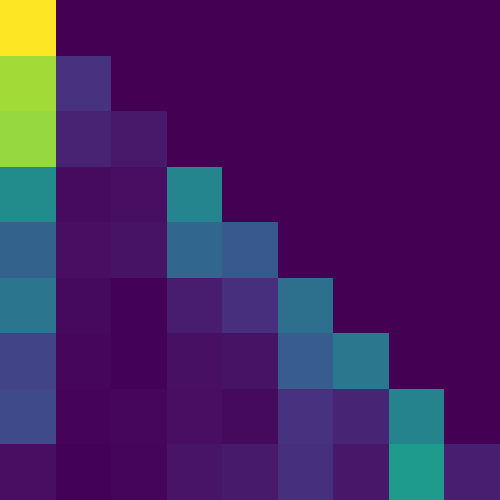
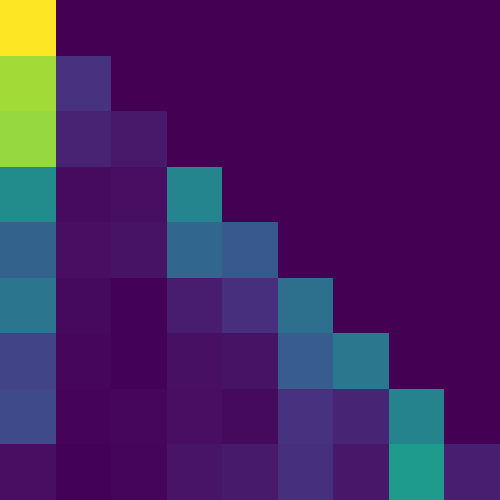
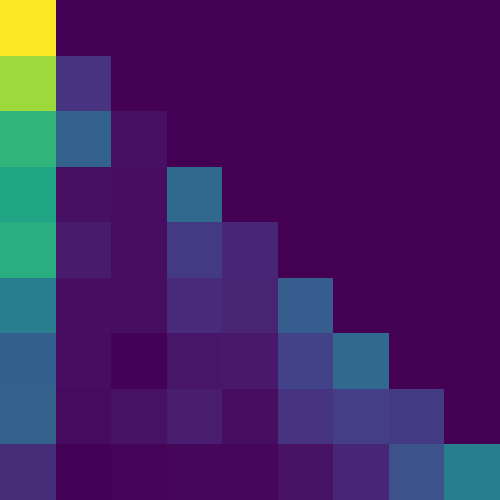
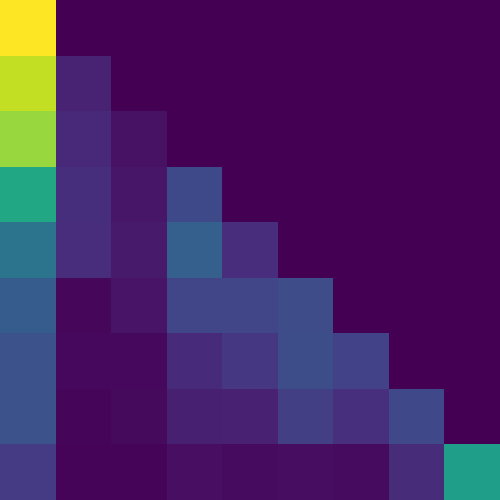
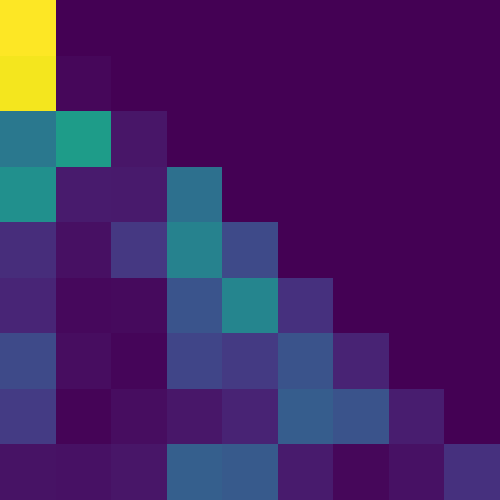
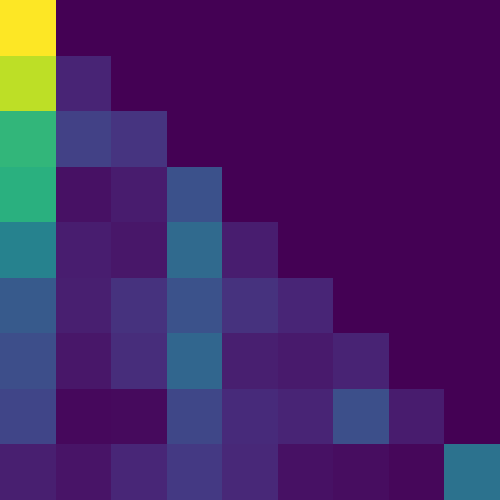
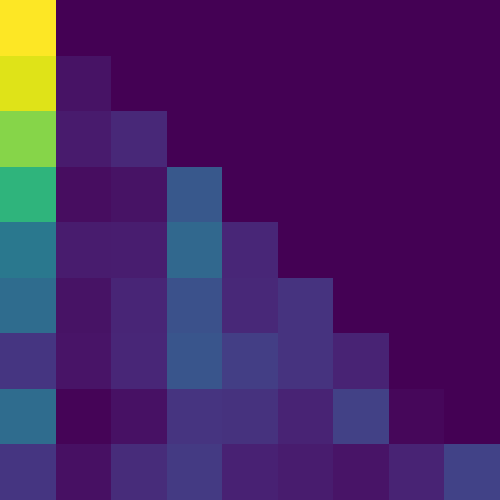
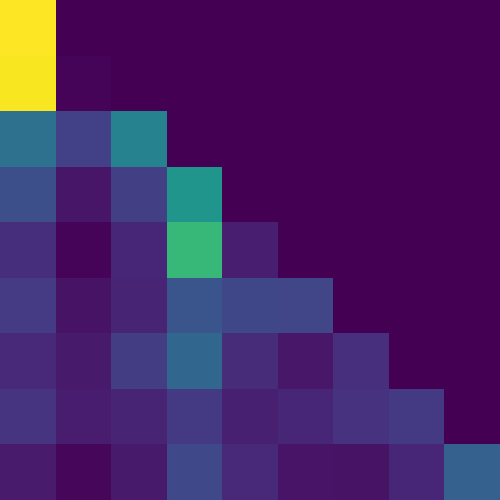
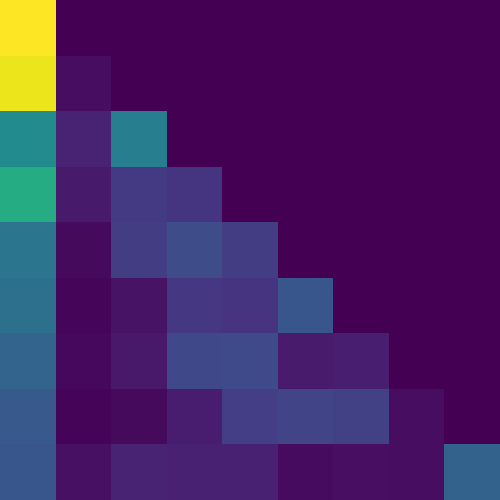
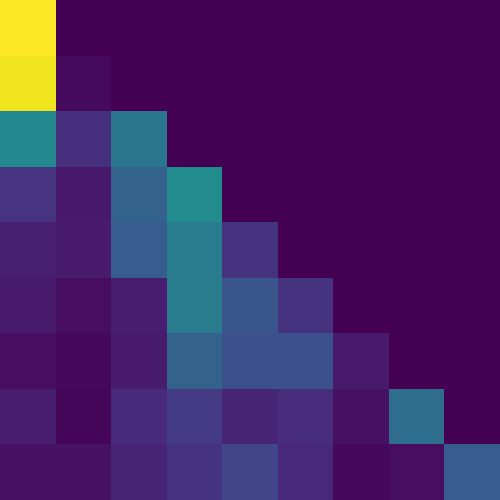
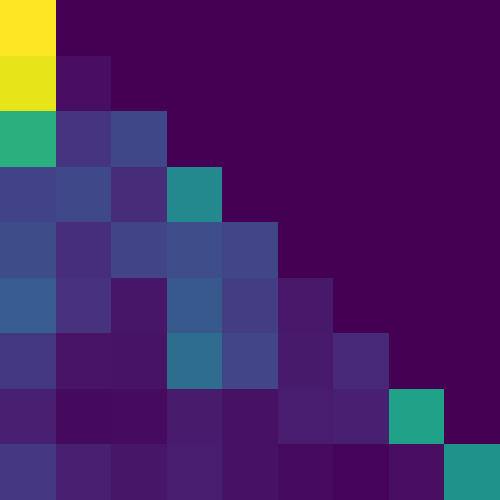
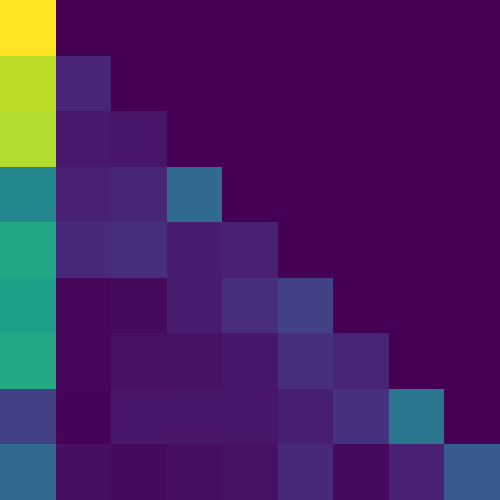
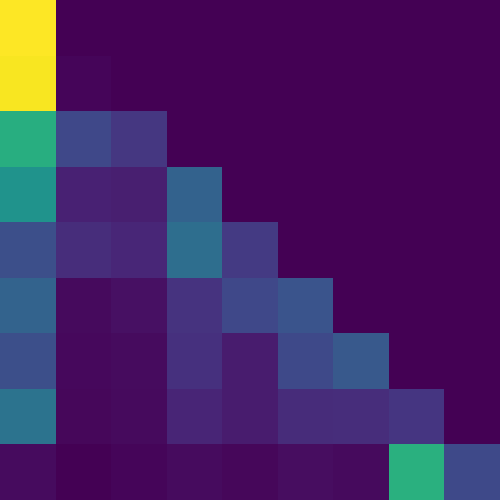
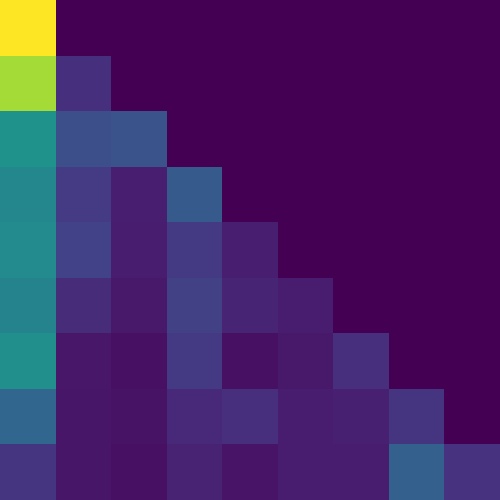
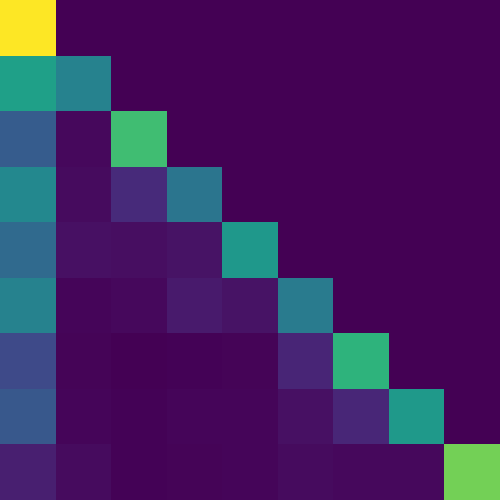
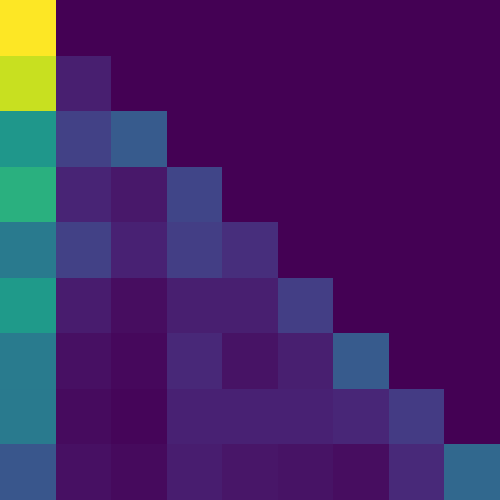
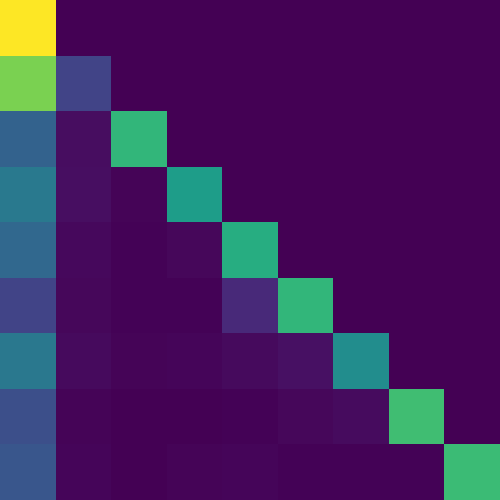
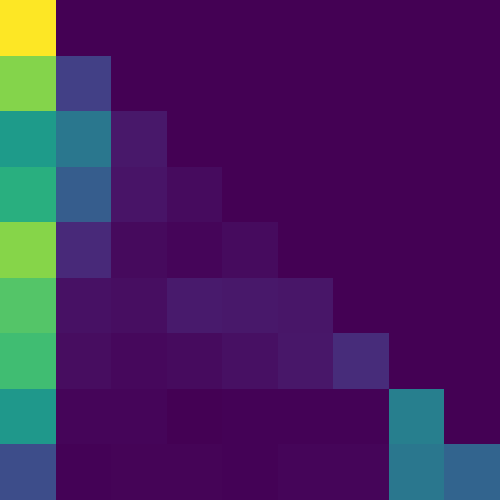
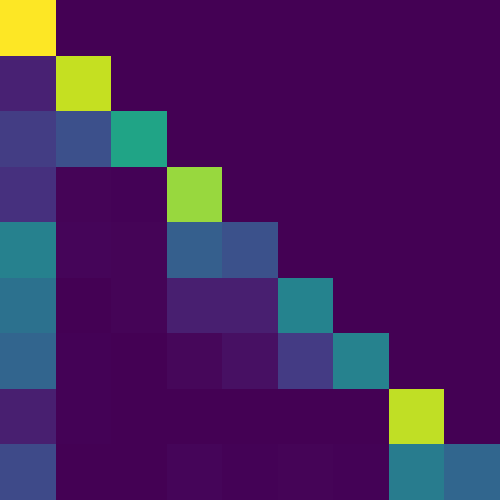
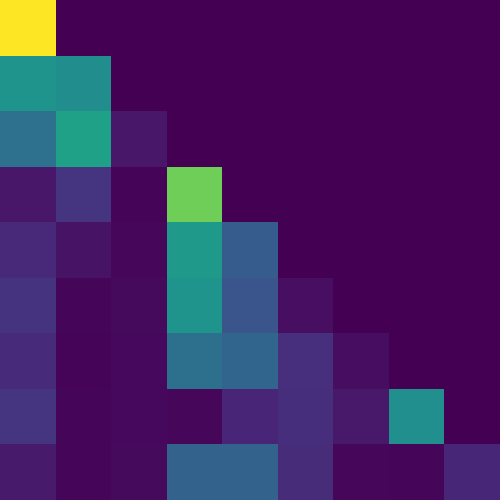
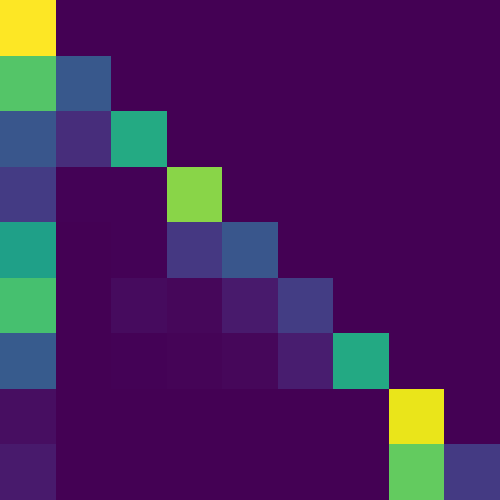
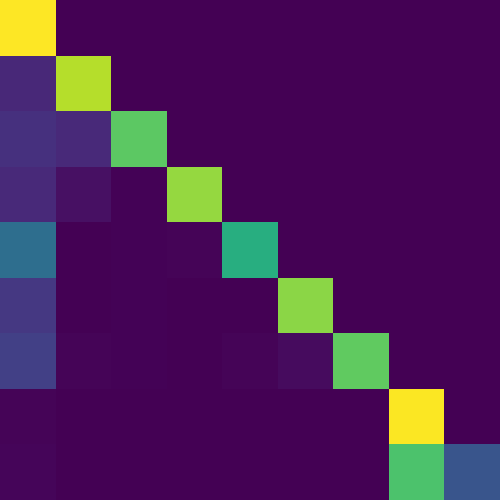
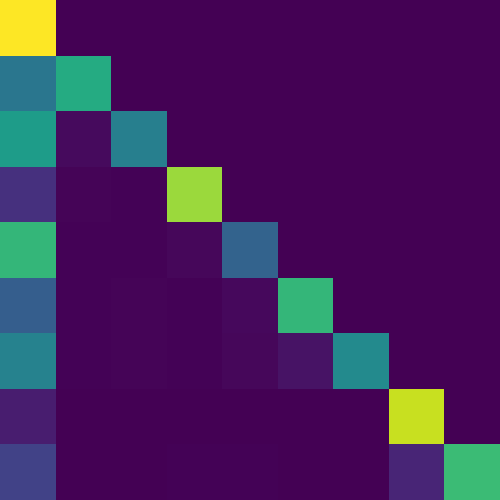
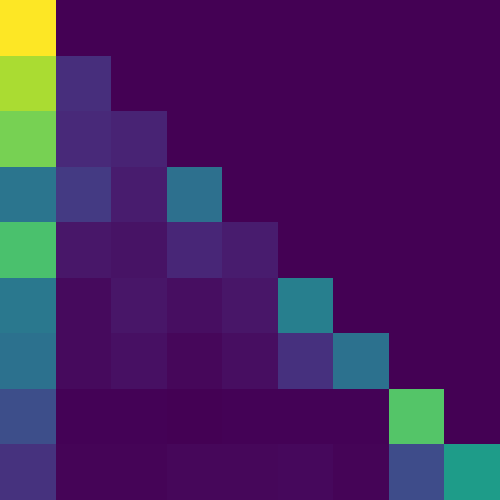
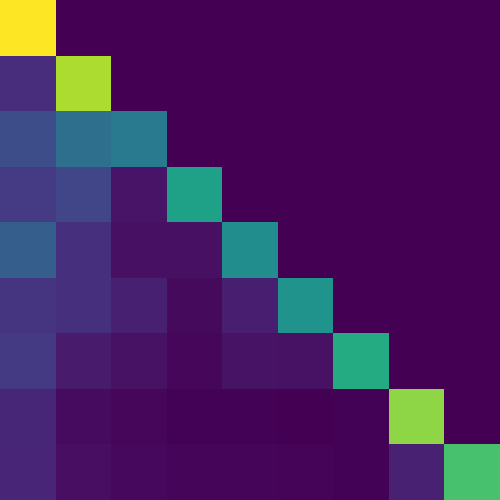
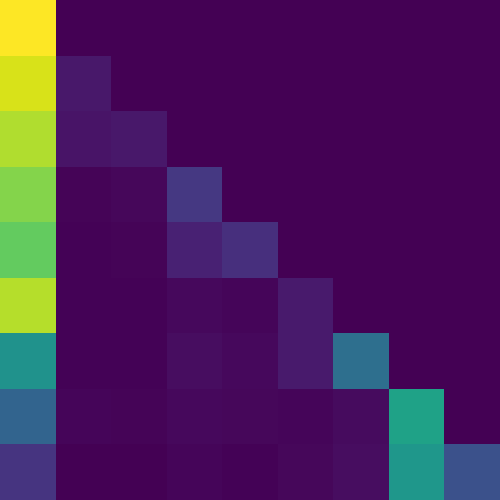
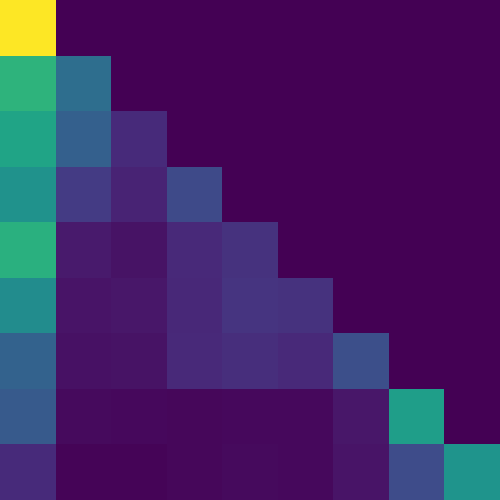
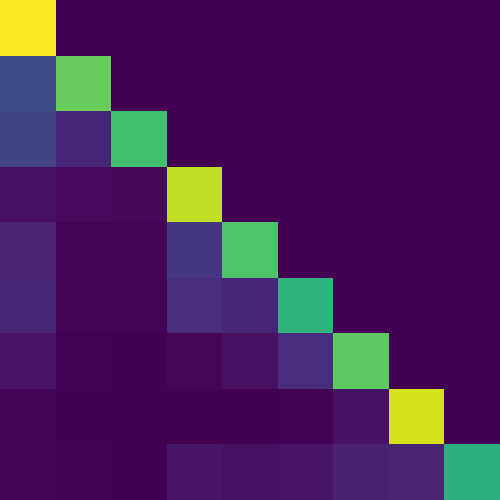
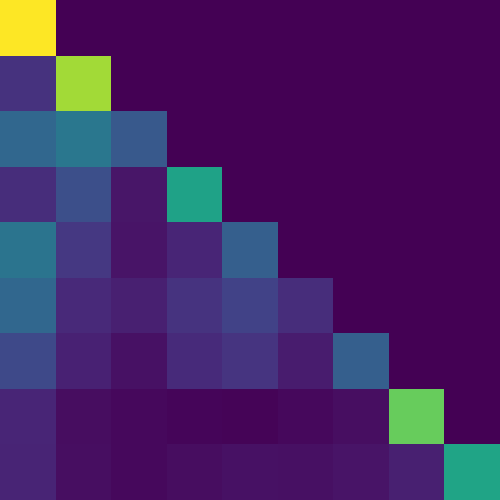
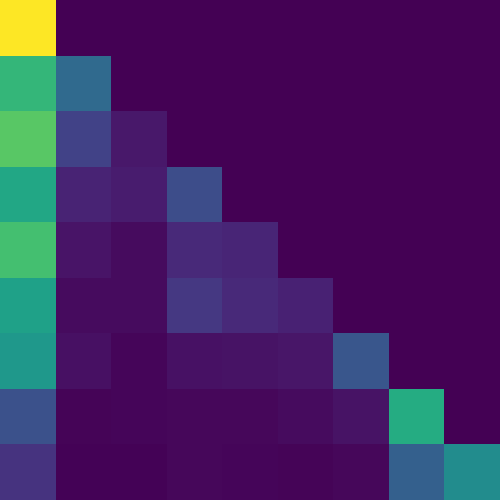
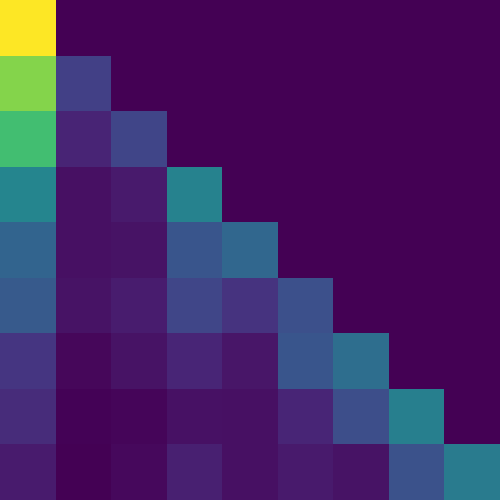
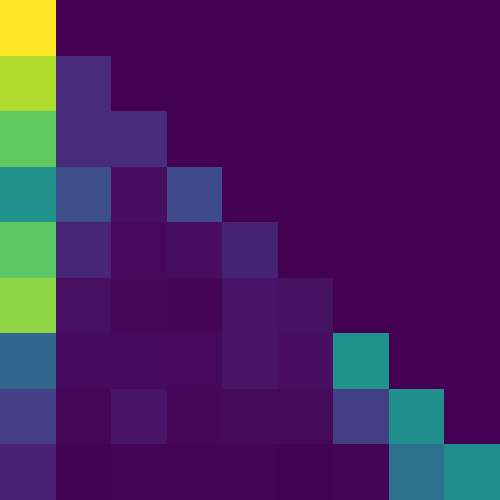
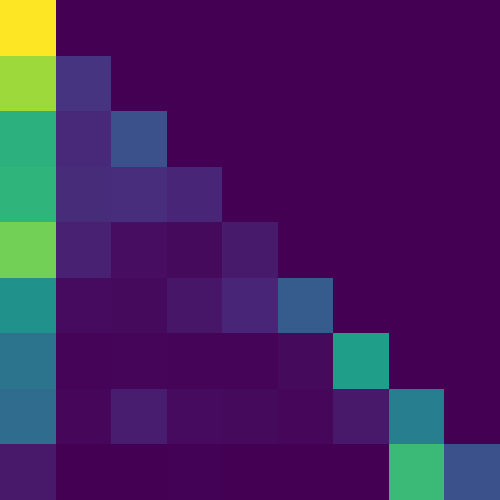
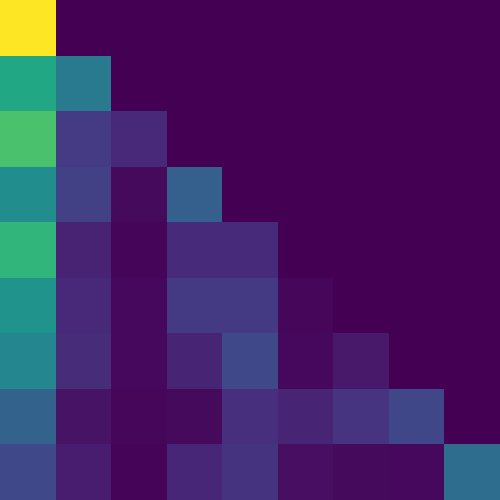
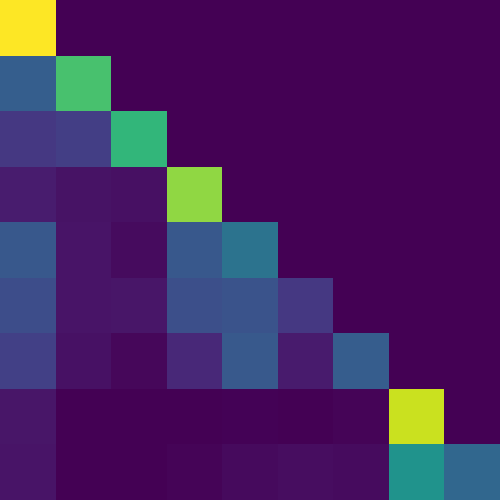
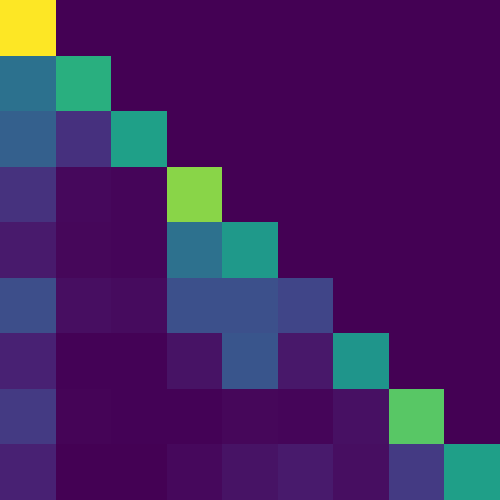
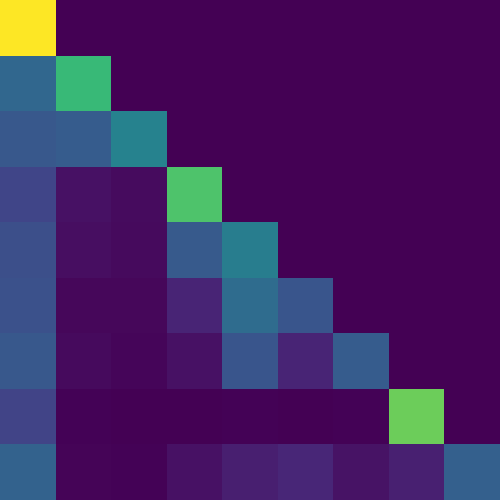
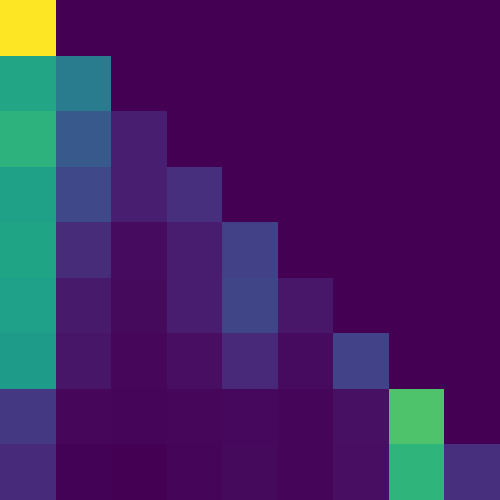
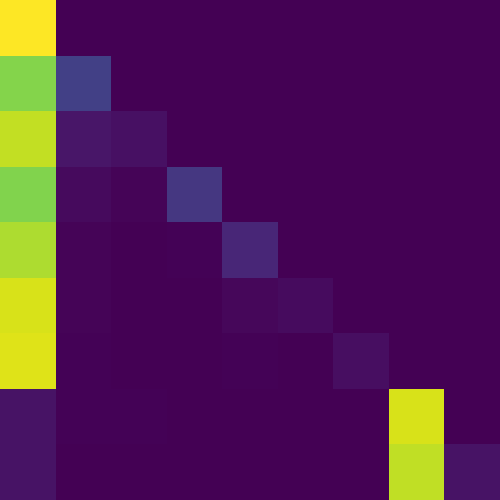
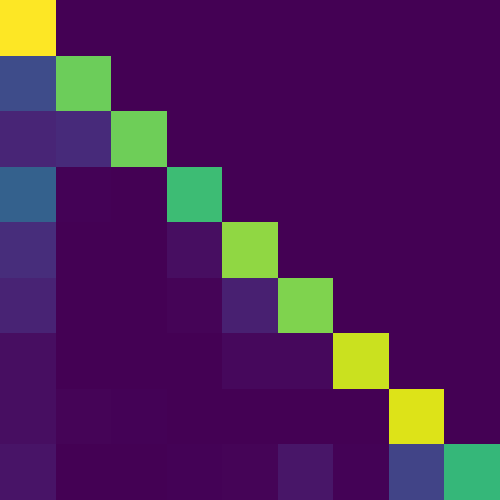
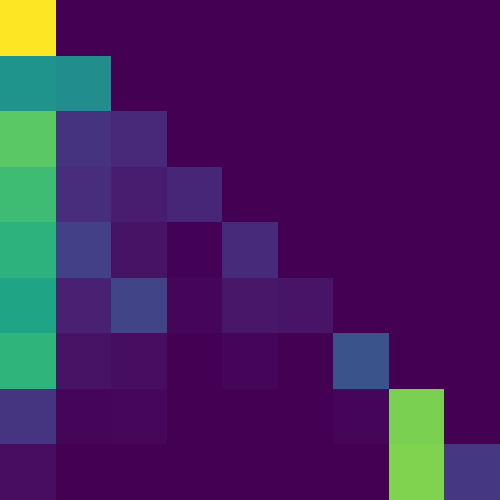
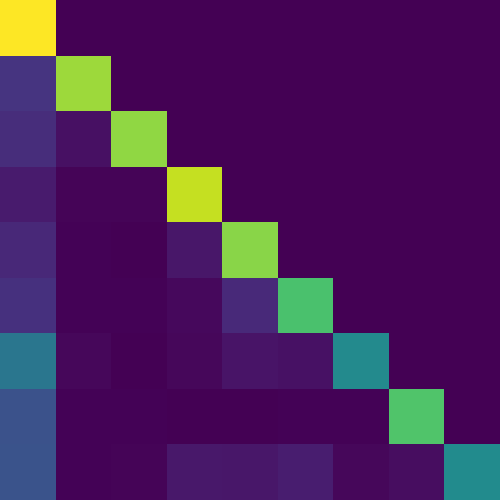
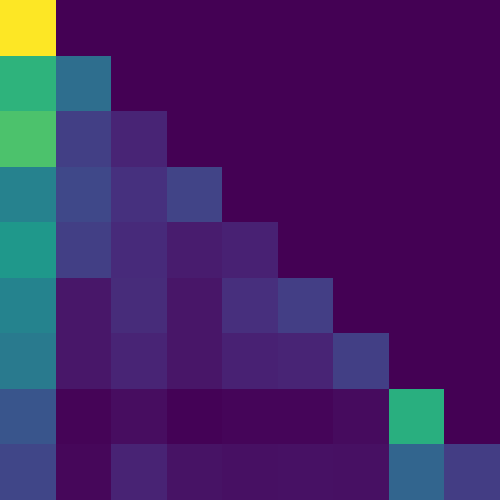
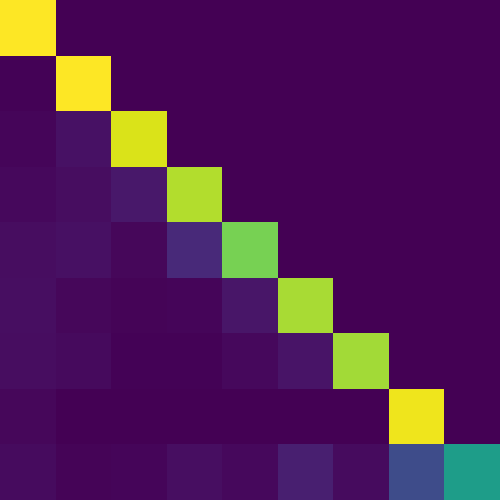
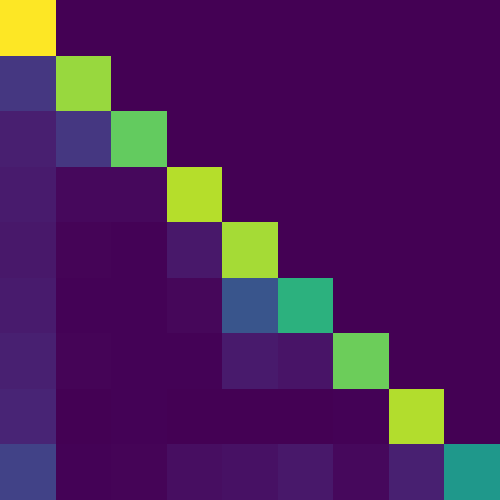
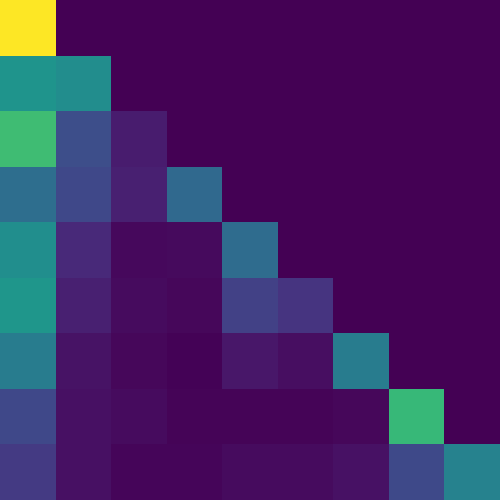
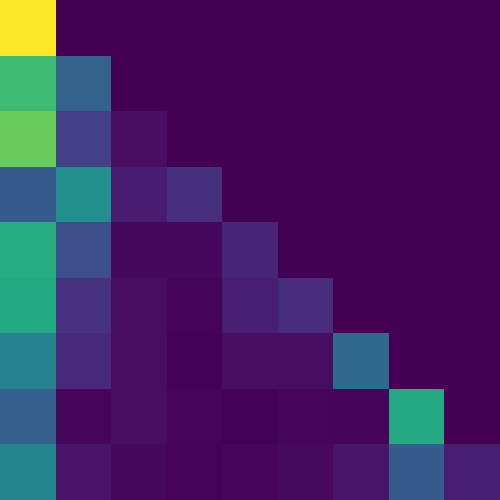
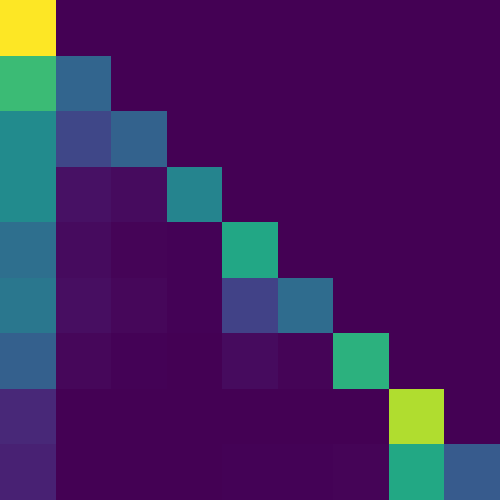
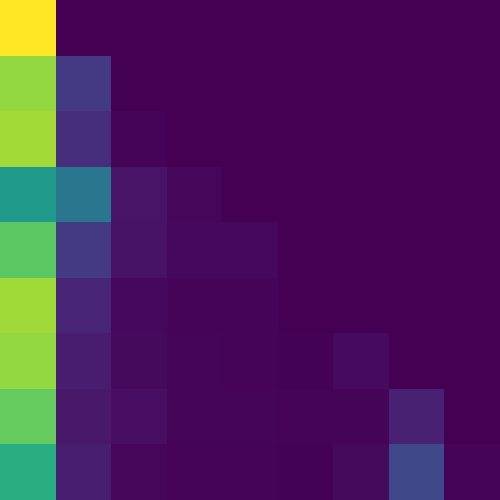
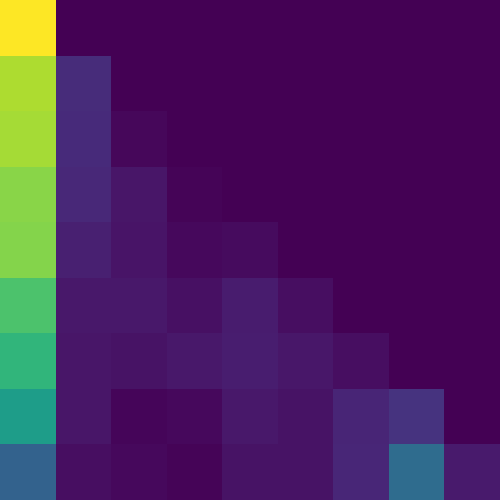
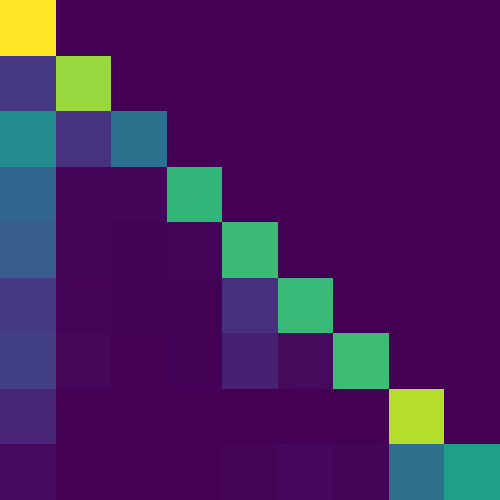
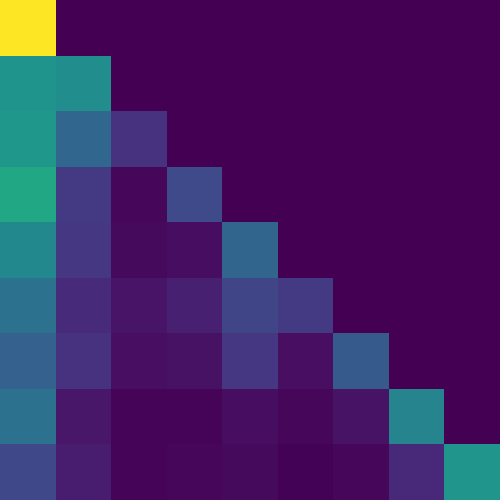
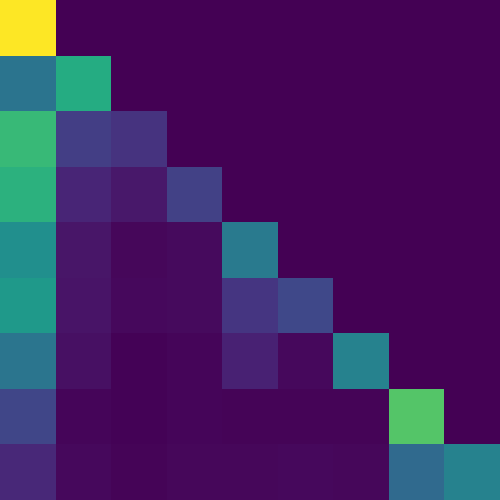
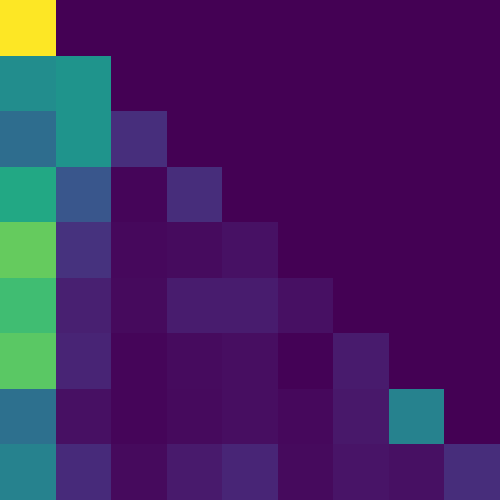
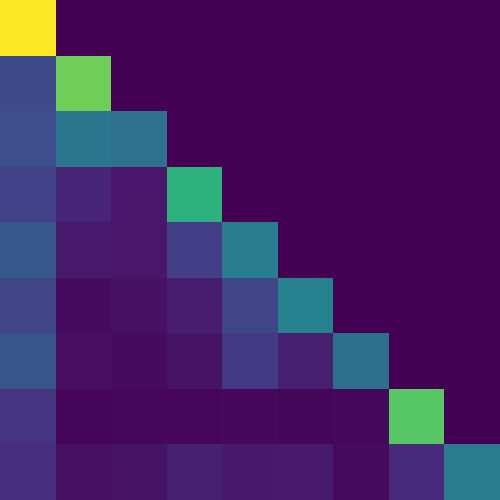
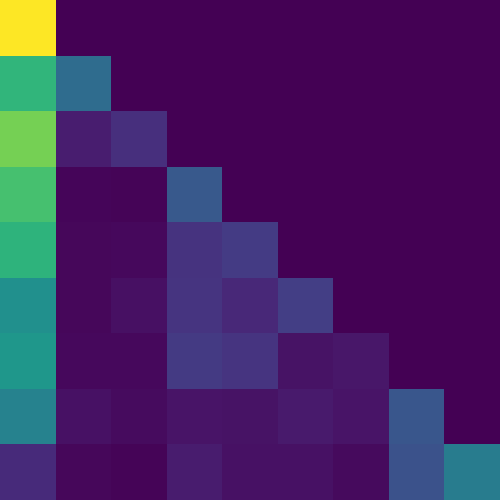
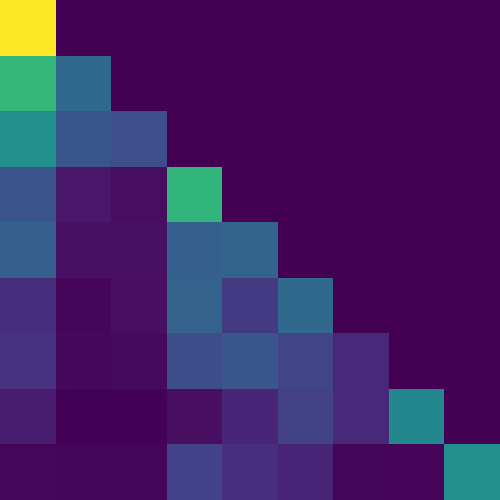
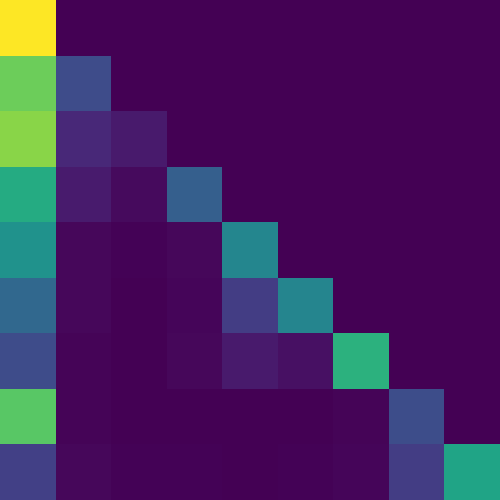
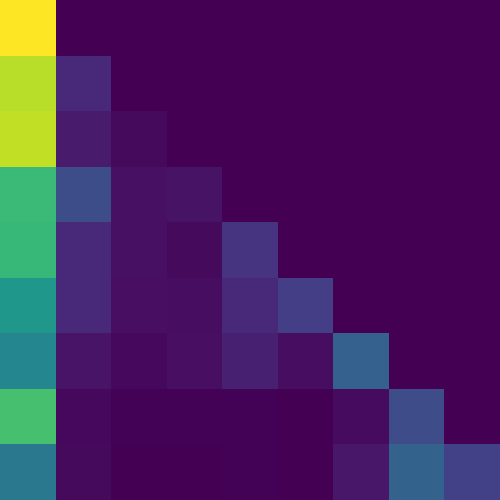
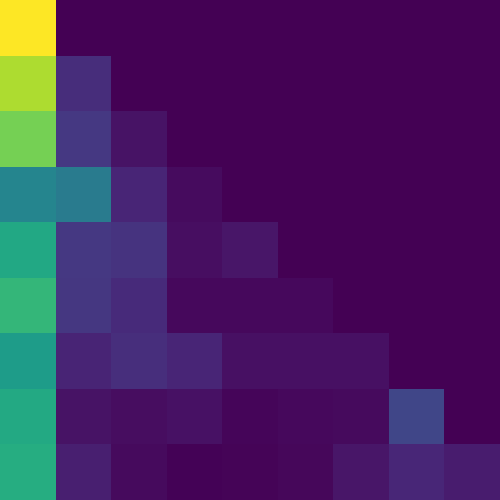
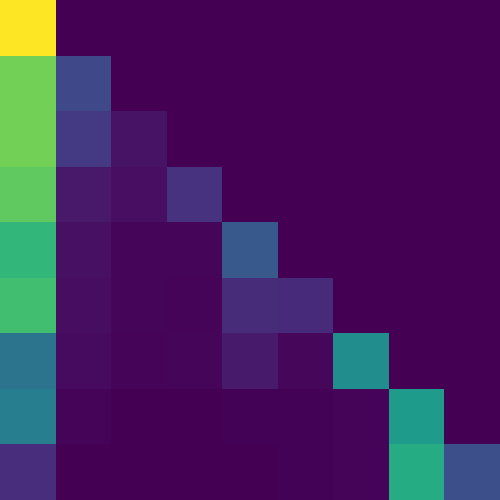
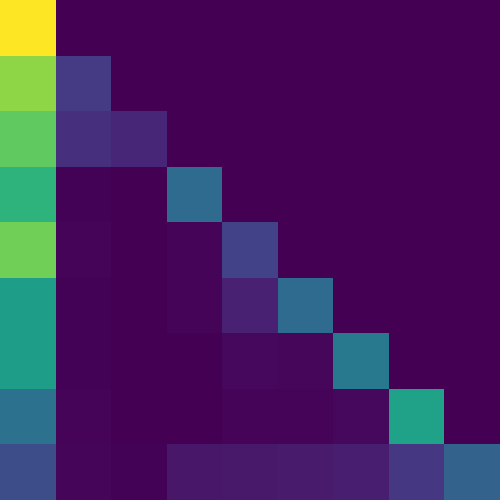
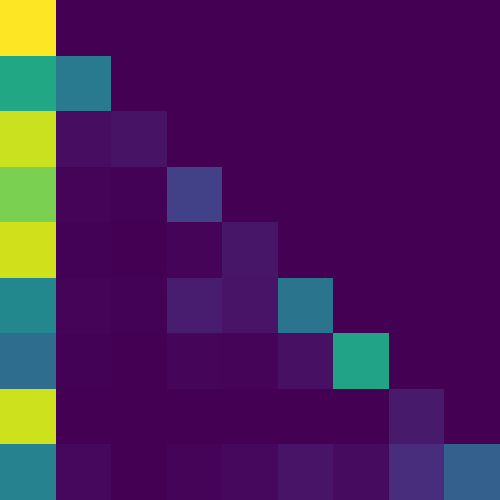
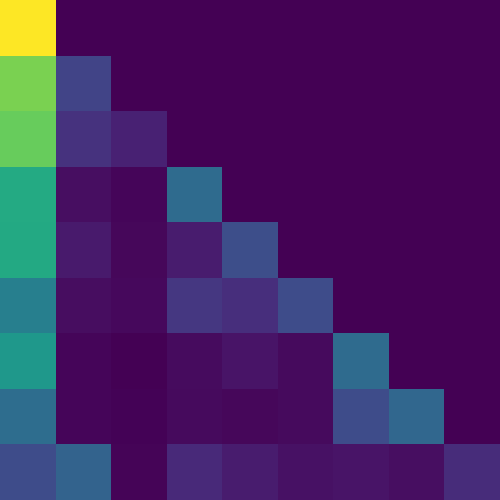
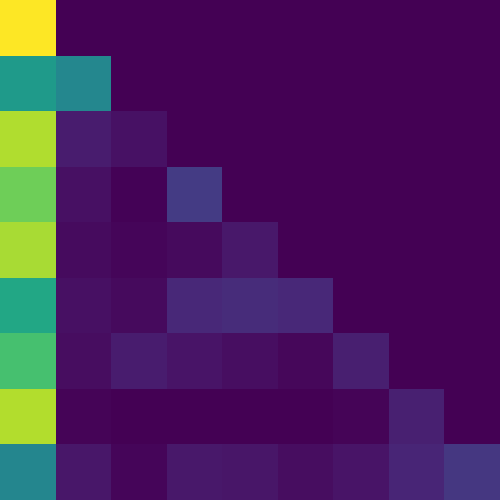
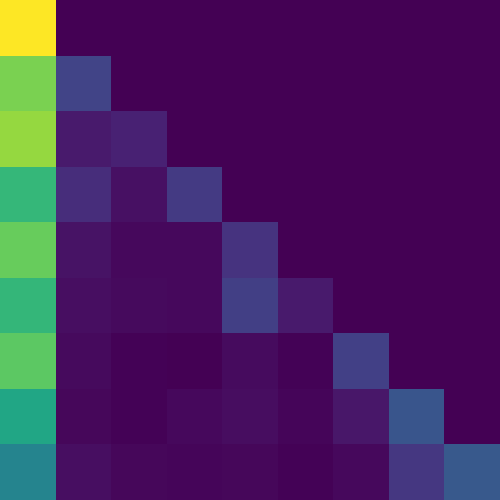
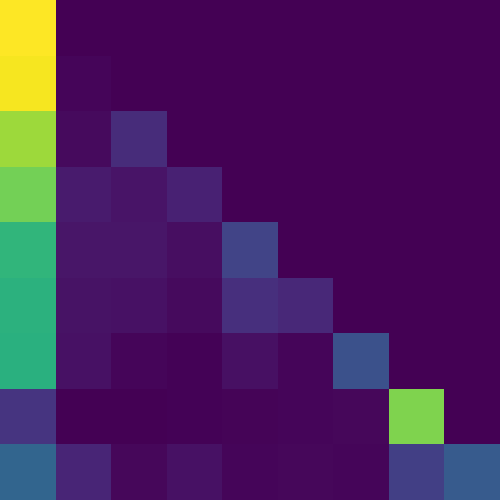
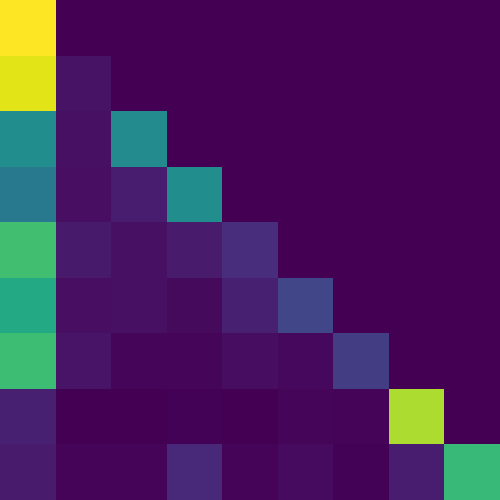
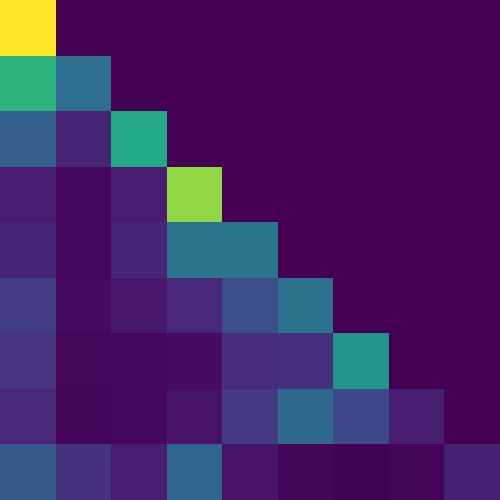
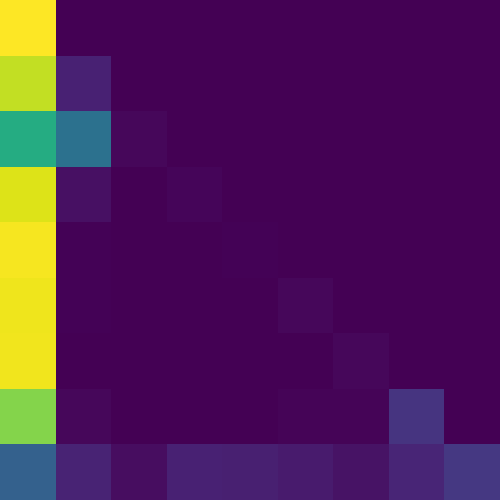
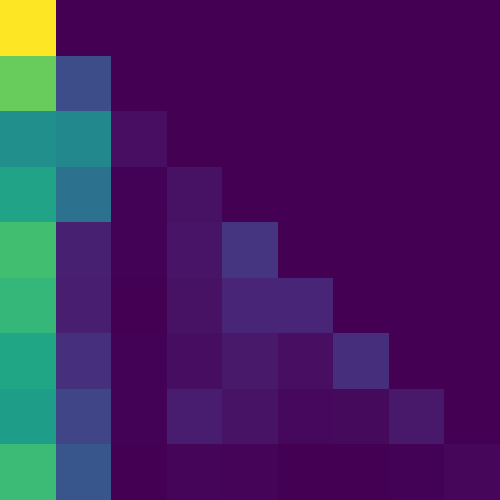
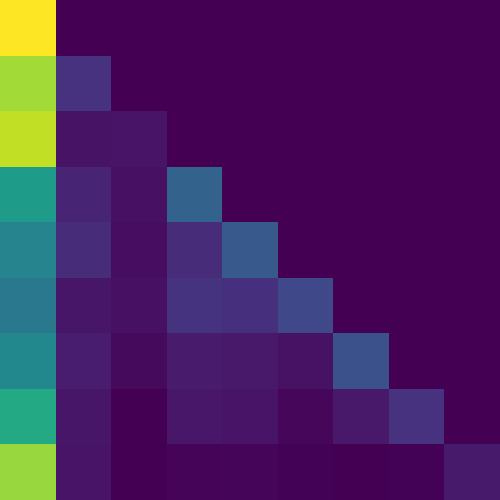
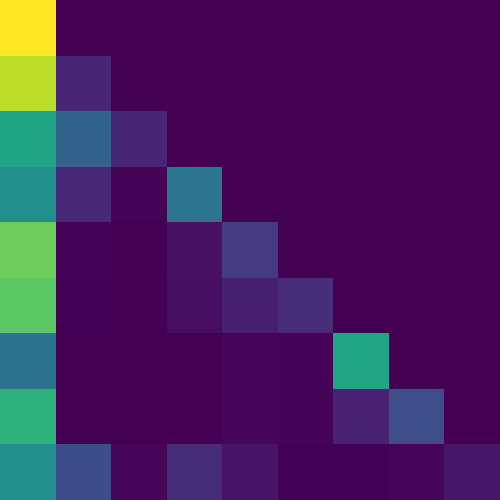
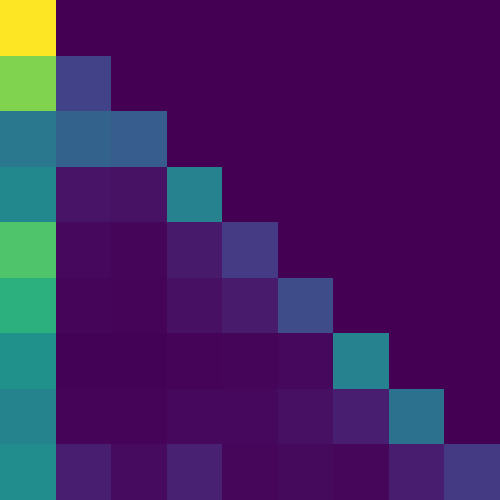
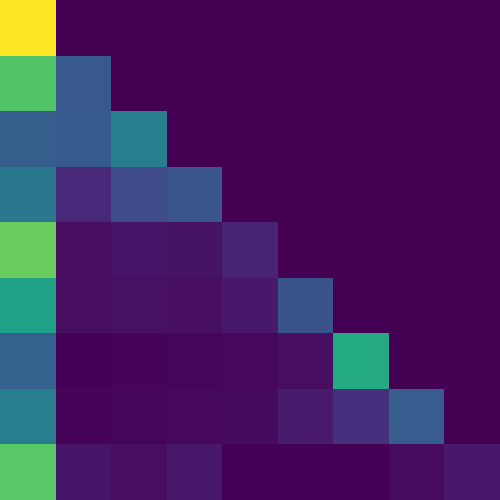
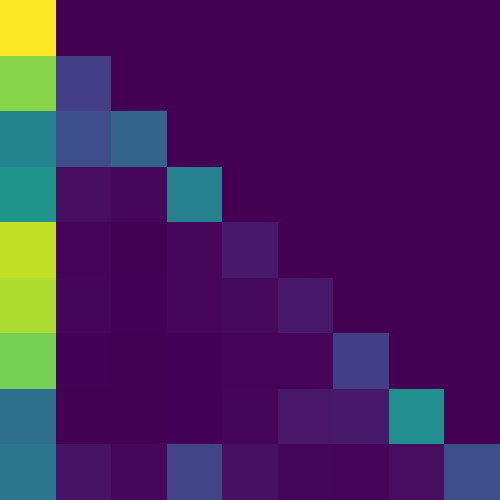
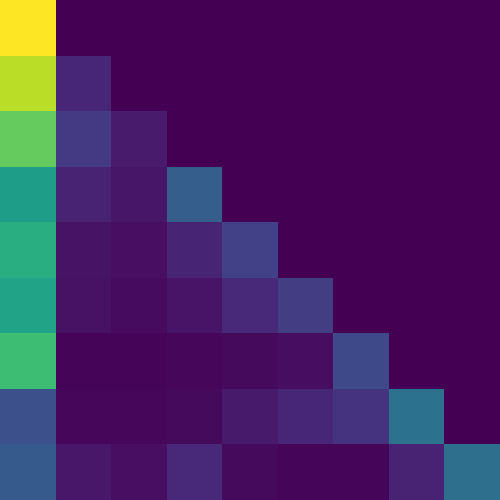
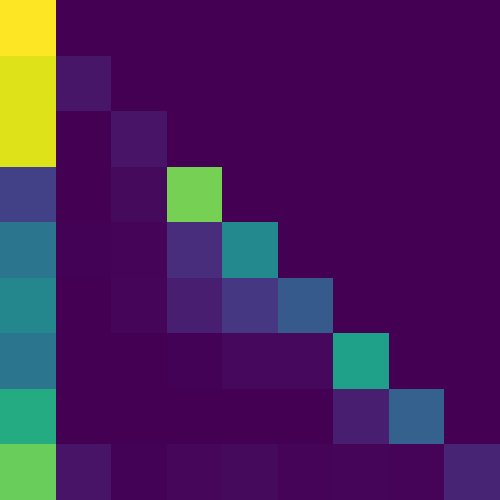
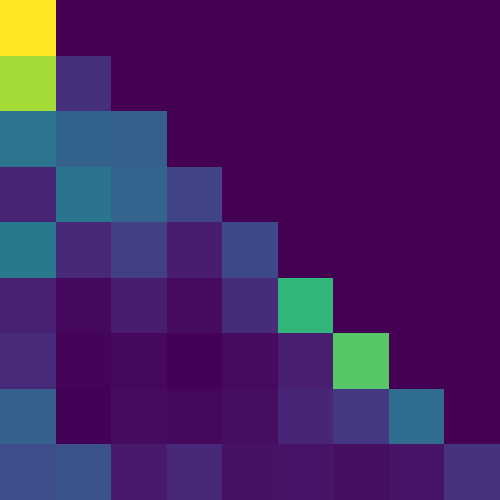
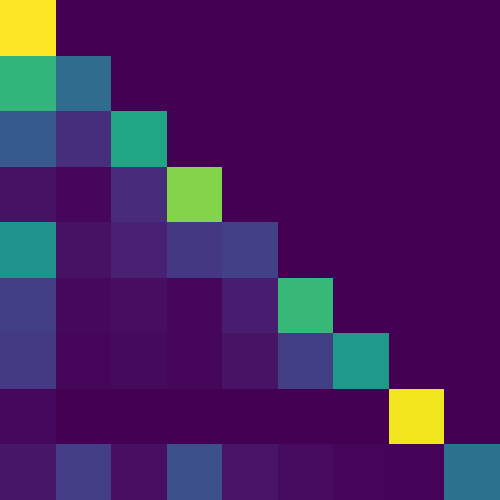
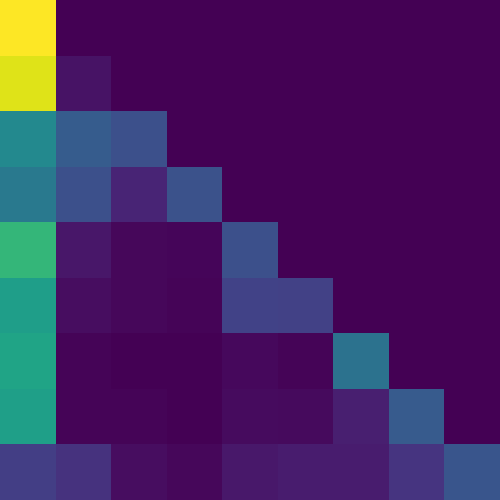
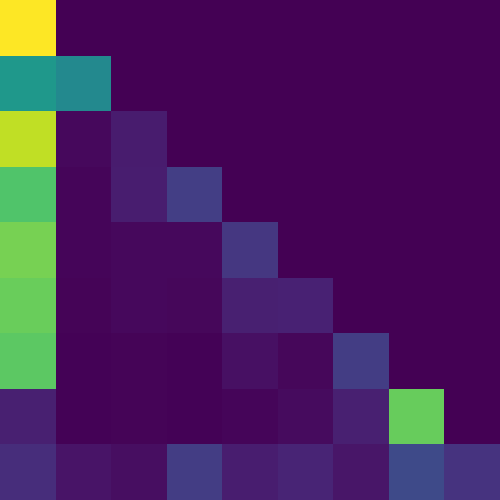
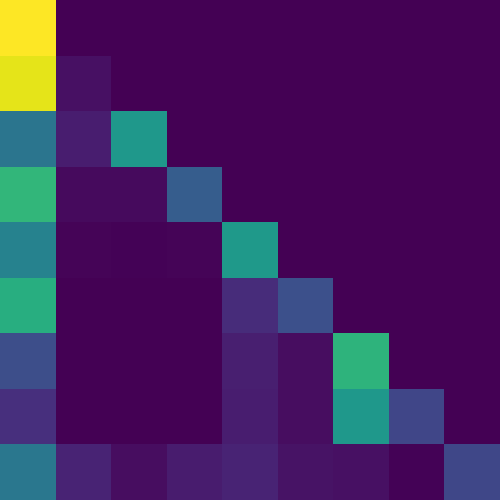
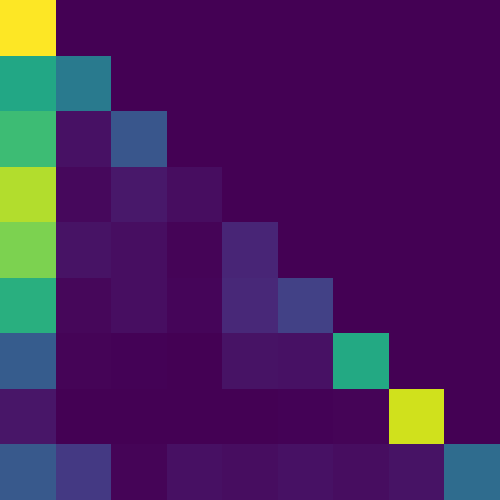
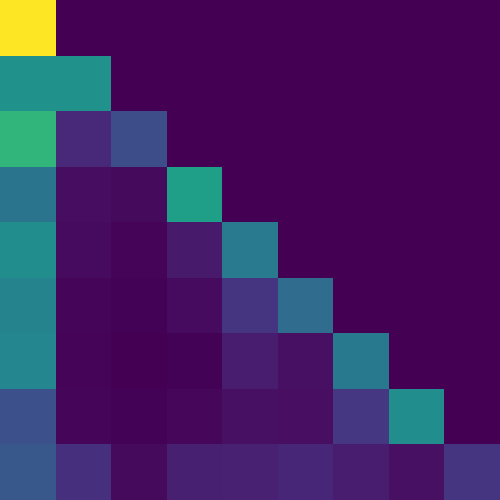
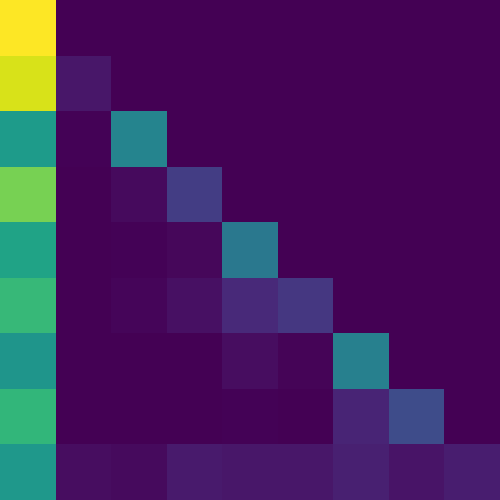
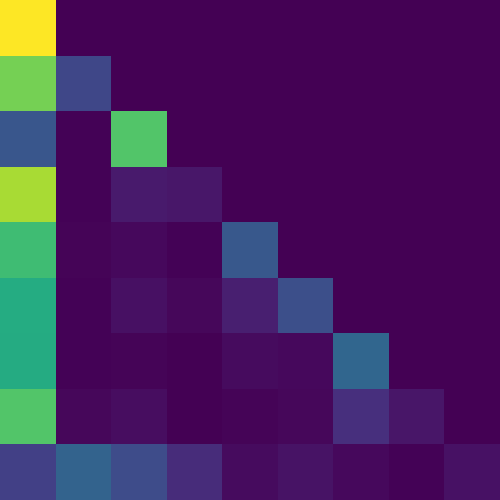
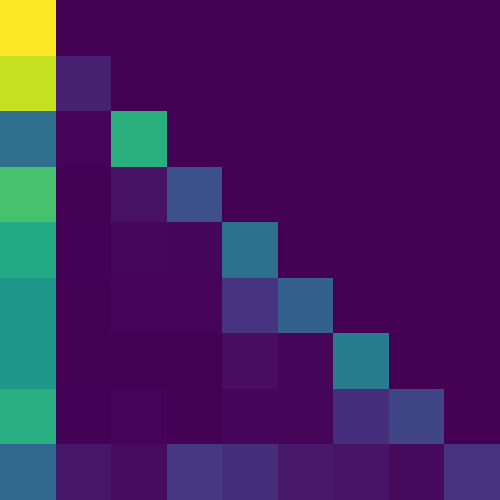
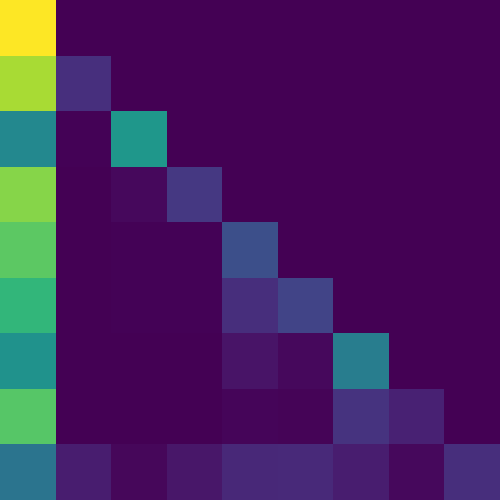
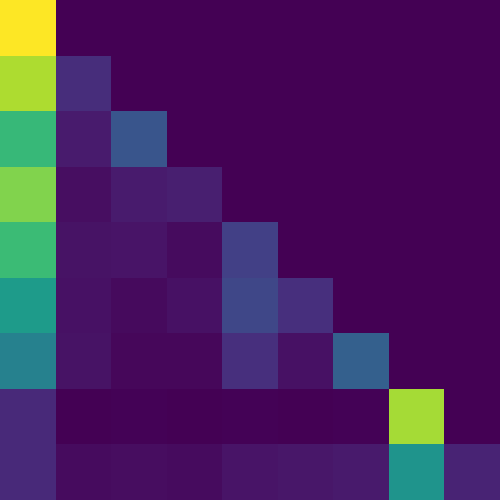
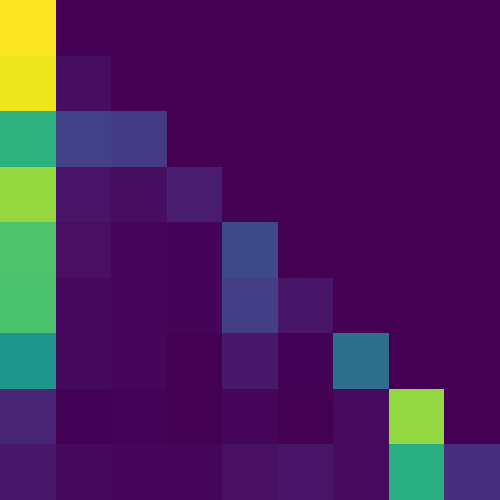
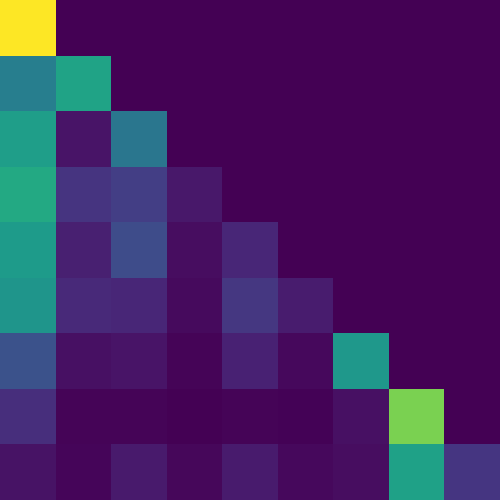
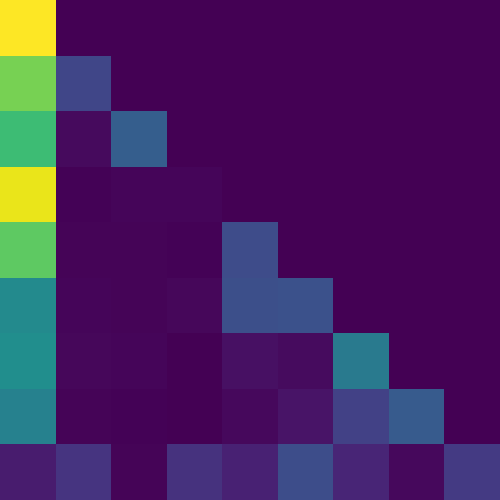
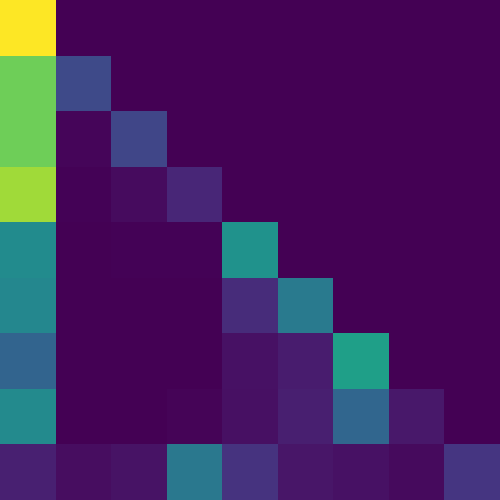
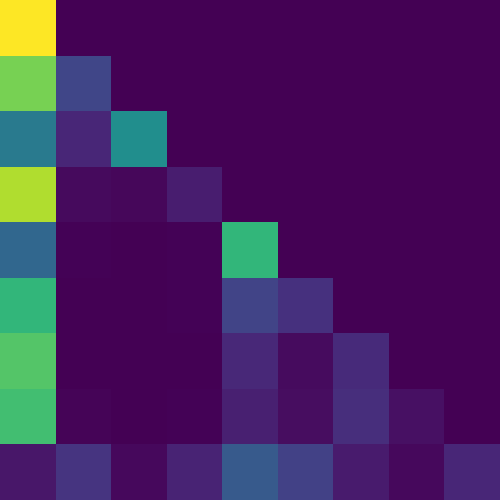
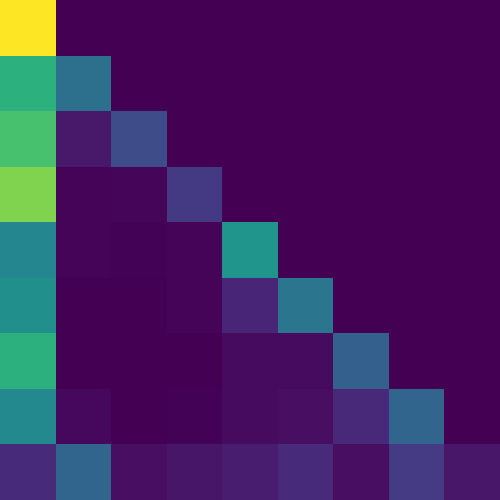
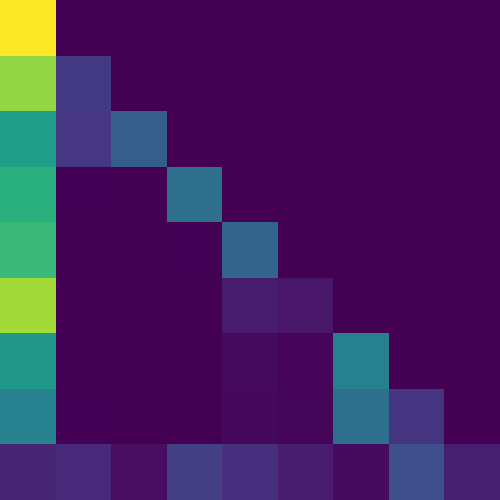
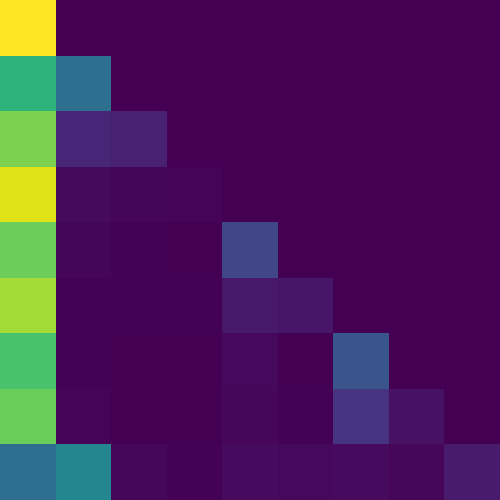
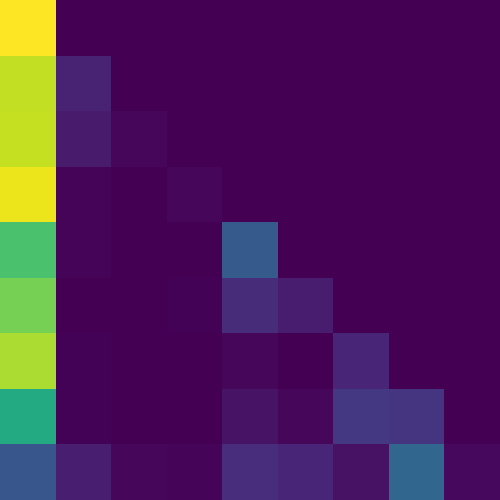
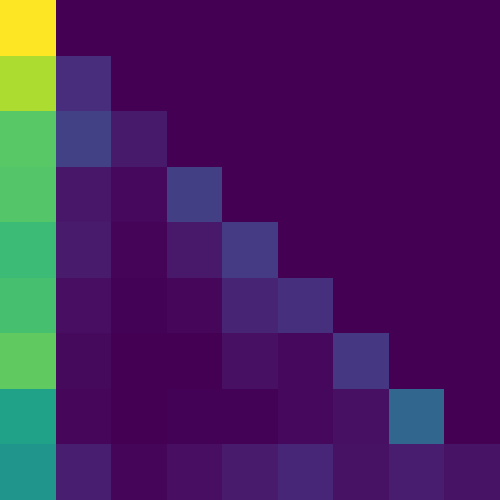
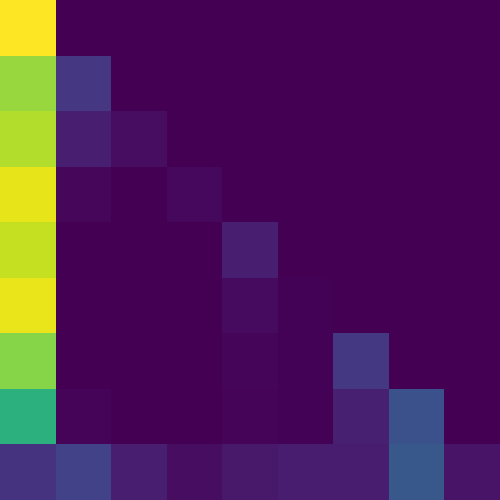
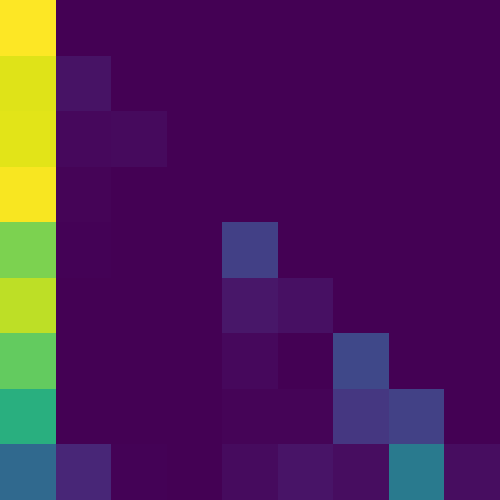
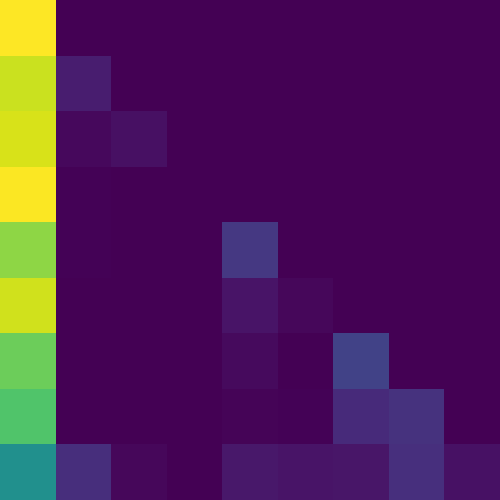
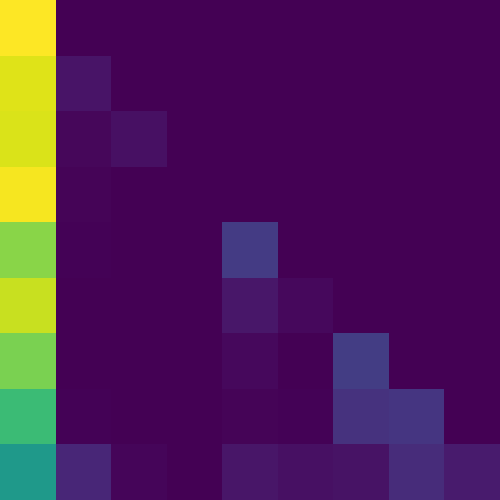
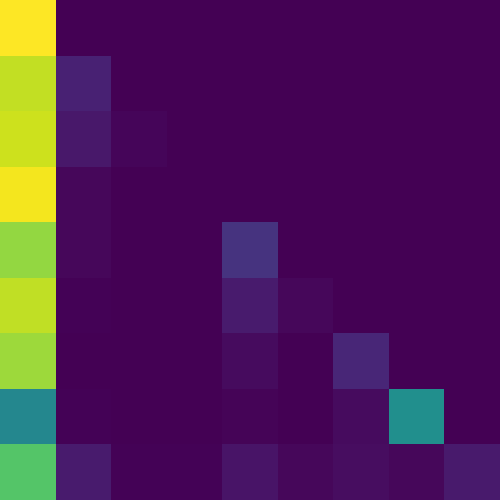
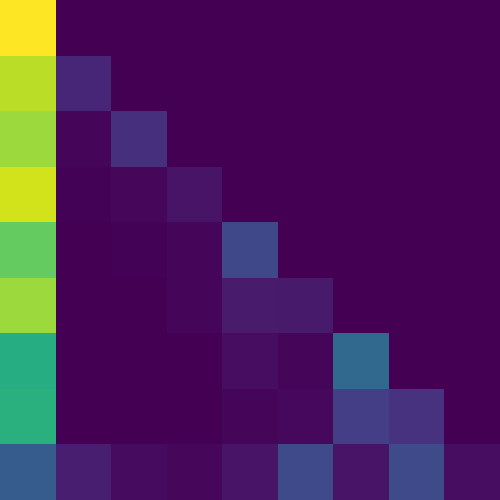
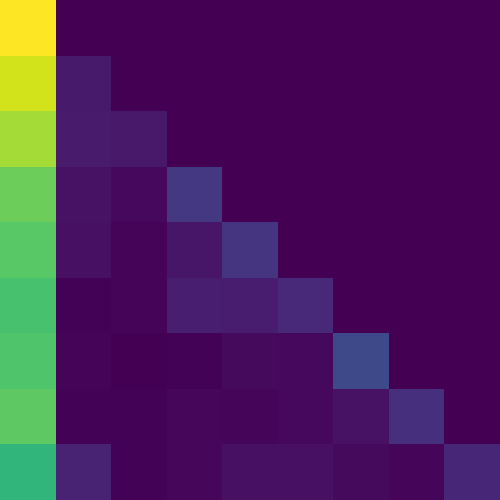
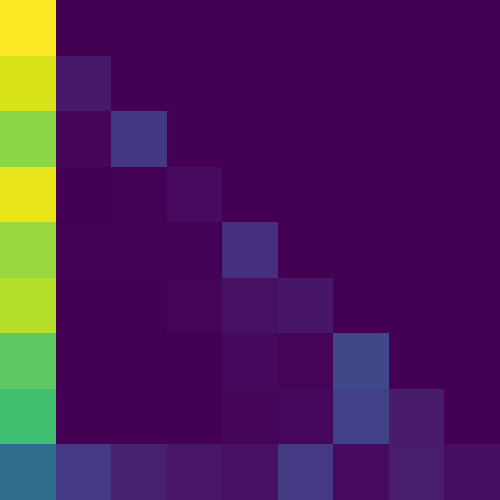
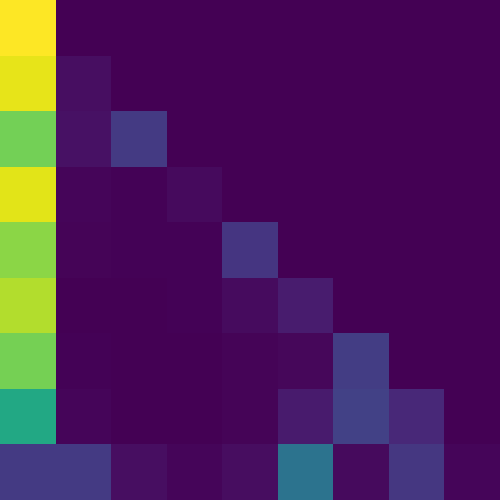
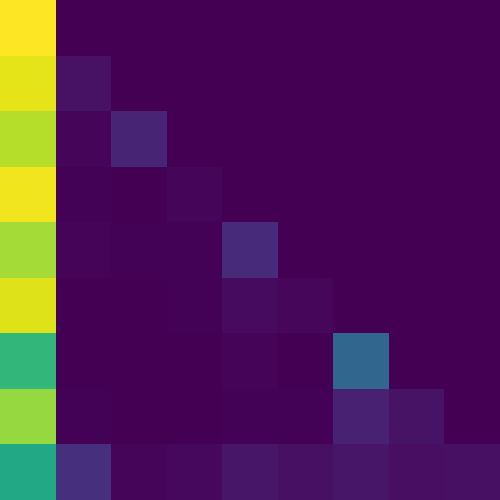
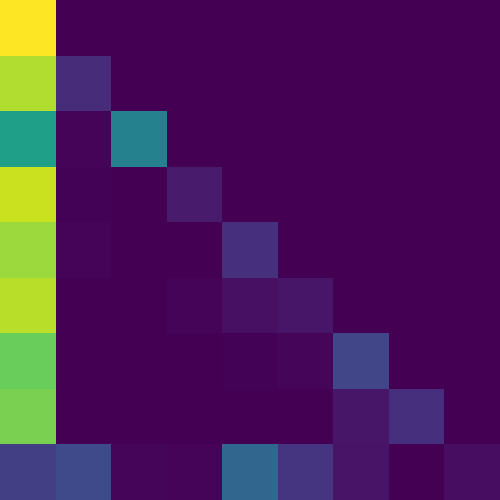
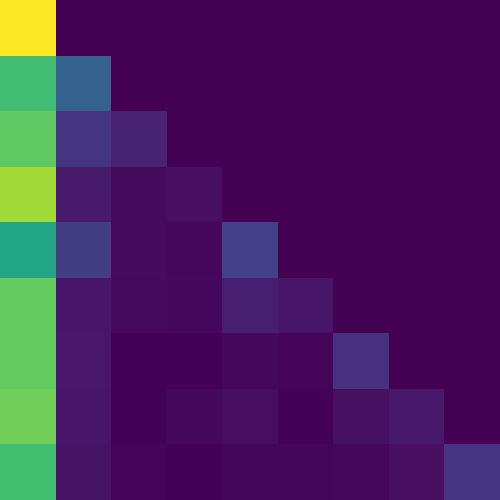
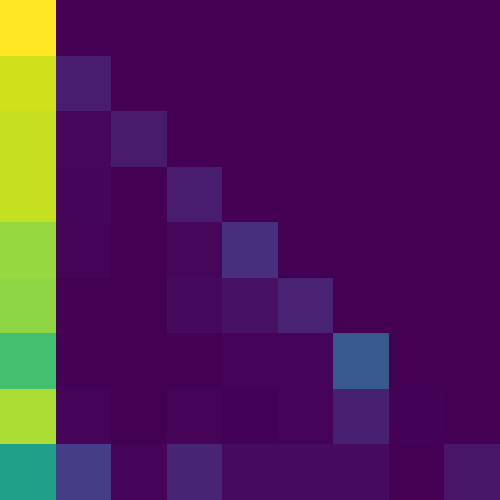
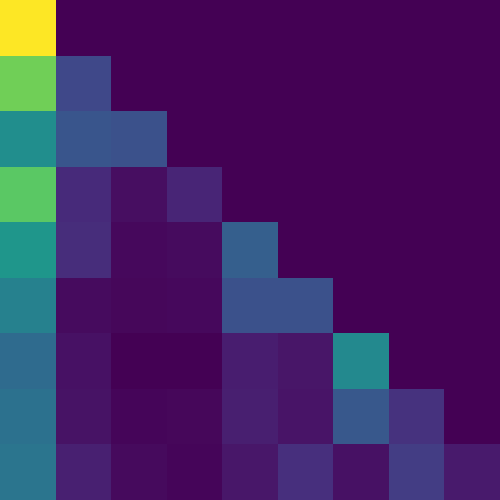
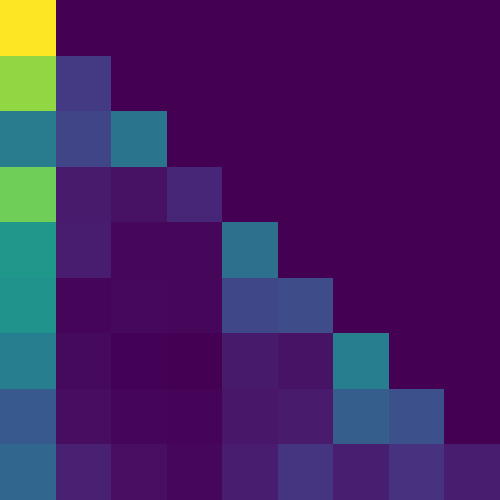
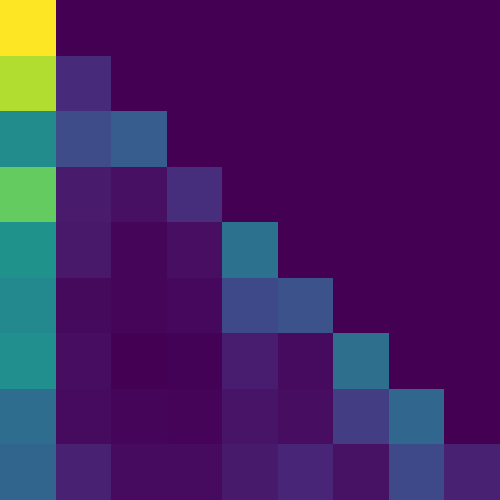
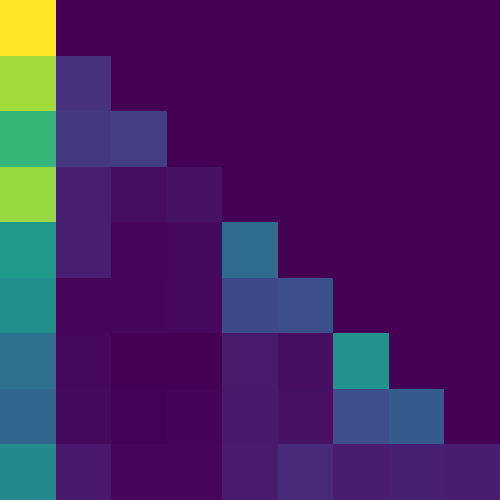
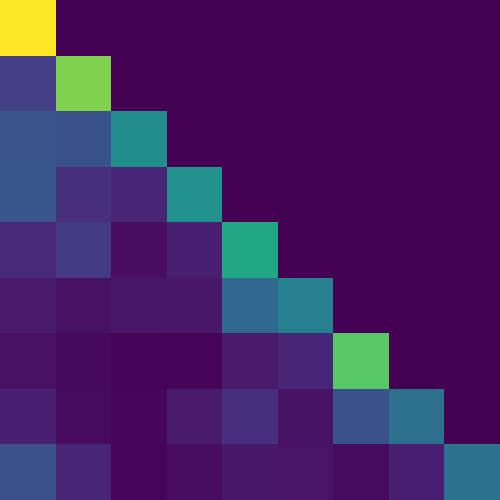
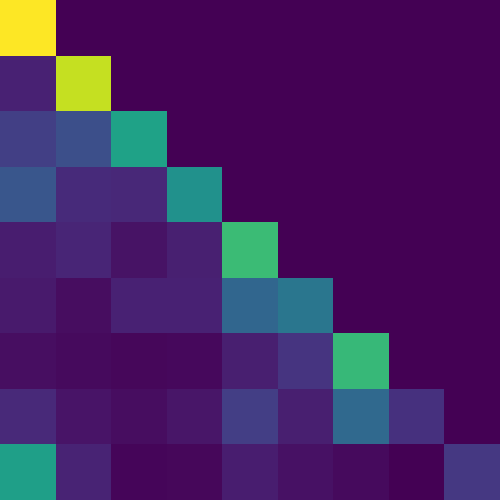
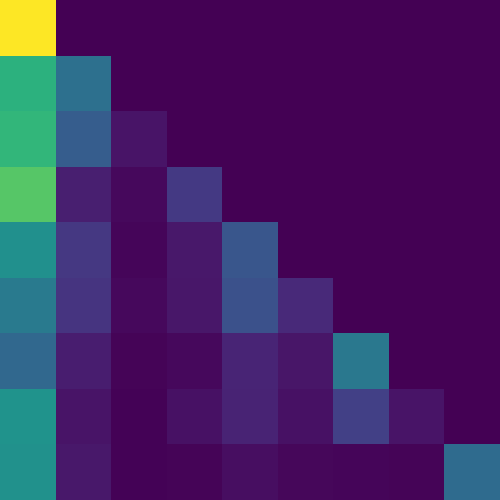
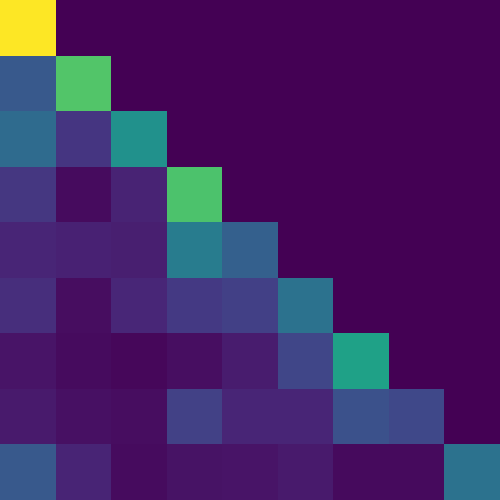
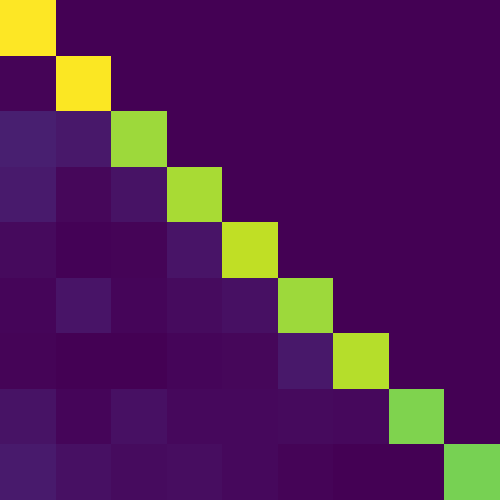
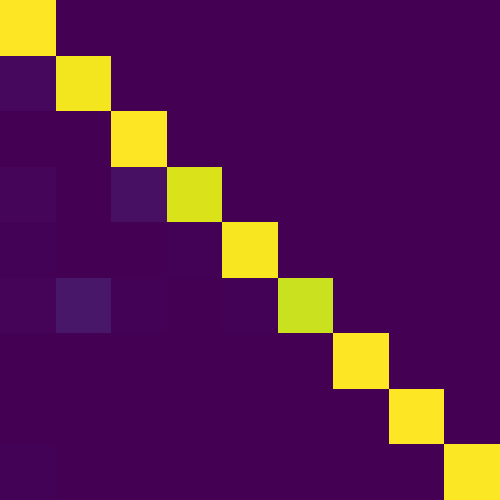
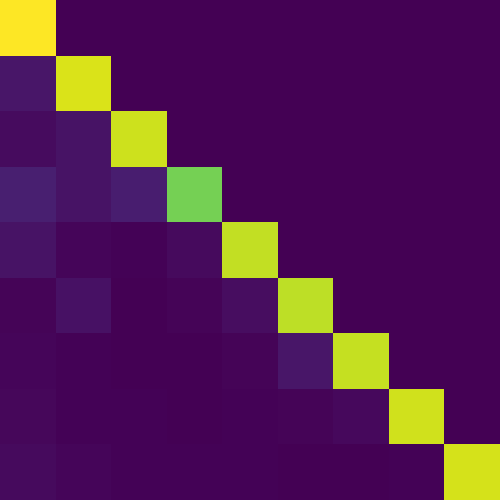
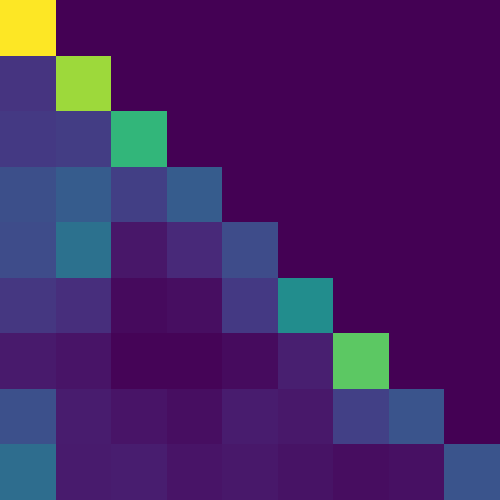
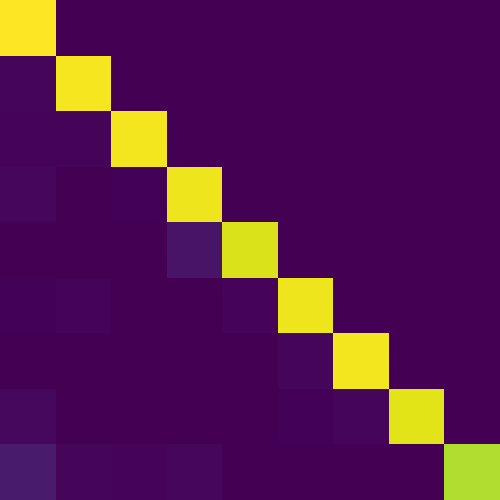
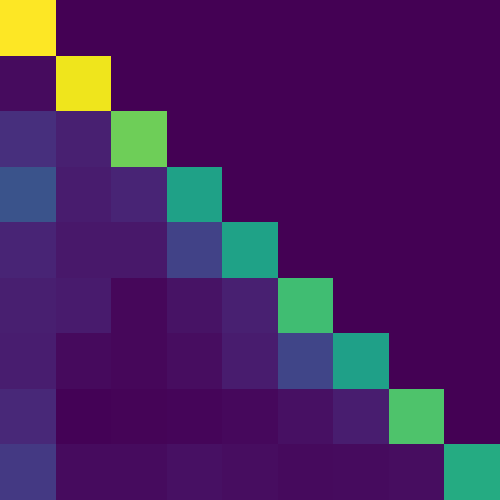
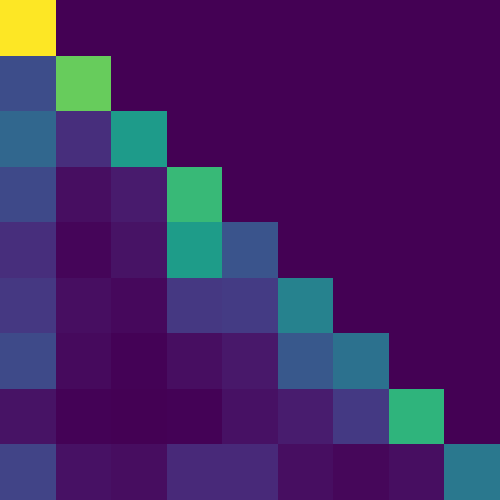
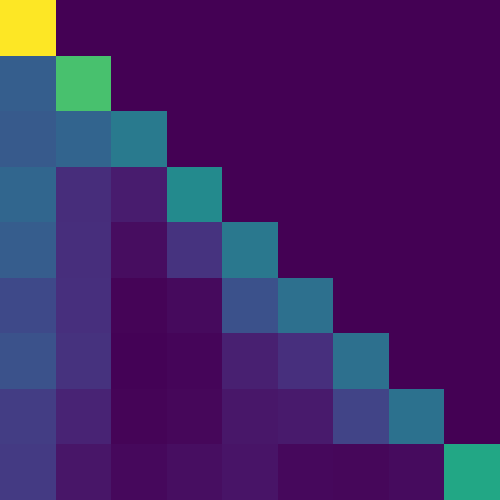

Widget loaded successfully!

[Backend] Generating custom GIF: 50ms per frame, 1000x1000px...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


[Backend] Generating custom GIF: 50ms per frame, 500x500px...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
# Cell 10: Interactive Widget (Play once, Return to Start, Scale, Save Variant)
import glob
import base64
import json
import os
from IPython.display import HTML, display
from PIL import Image

# Use Google Colab's output module to register backend Python callbacks
try:
    from google.colab import output, files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print("Preparing interactive widget... (Packing frames, this may take a few seconds)")

# Gather the clean images generated in Cell 9
image_paths = sorted(glob.glob("clean-heads/clean_layer_*_head_*.png"))

if not image_paths:
    print("Error: No clean images found. Please run Cell 9 first.")
else:
    # 1. Base64 encode all images so JavaScript can play them flawlessly without network lag
    b64_frames = []
    for p in image_paths:
        with open(p, "rb") as f:
            encoded = base64.b64encode(f.read()).decode('ascii')
            b64_frames.append(f"data:image/png;base64,{encoded}")

    # 2. Define the Python Callback to handle the "Save Variant" button
    def save_custom_variant(is_fast, is_scaled):
        speed_ms = 50 if is_fast else 150
        size = (1000, 1000) if is_scaled else (500, 500)

        print(f"\n[Backend] Generating custom GIF: {speed_ms}ms per frame, {size[0]}x{size[1]}px...")

        frames = []
        for p in image_paths:
            img = Image.open(p)
            if is_scaled:
                # Resize using NEAREST to preserve the sharp grid edges of the heatmap
                img = img.resize(size, Image.NEAREST)
            frames.append(img)

        out_name = f"custom_variant_{speed_ms}ms_{size[0]}px.gif"

        # Omit 'loop' parameter so the saved GIF mimics the widget (plays once and stops)
        # If you want it to loop infinitely, add `loop=0` below duration.
        frames[0].save(
            out_name,
            format='GIF',
            append_images=frames[1:],
            save_all=True,
            duration=speed_ms
        )

        if IN_COLAB:
            files.download(out_name)
            return "Downloaded via Colab!"
        else:
            return f"Saved locally to {os.path.abspath(out_name)}"

    # Register the Python function so JavaScript can call it
    if IN_COLAB:
        output.register_callback('notebook.save_variant', save_custom_variant)

    # 3. HTML, CSS, and JavaScript for the interactive output
    html_code = f"""
    <div style="font-family: Arial, sans-serif; background: #22272e; color: #adbac7; padding: 20px; border-radius: 8px; border: 1px solid #444c56; max-width: max-content;">

        <h3 style="margin-top:0; color: #adbac7;">Heatmap Animator Dashboard</h3>

        <!-- Controls -->
        <div style="display: flex; gap: 15px; align-items: center; margin-bottom: 20px; flex-wrap: wrap;">
            <button id="runBtn" style="background: #007bff; color: white; border: none; padding: 10px 15px; border-radius: 5px; font-weight: bold; cursor: pointer; transition: 0.2s;">
                Run Query
            </button>

            <label style="cursor: pointer; display: flex; align-items: center; gap: 5px;">
                <input type="checkbox" id="fastCheck" checked style="width: 16px; height: 16px;">
                Fast Velocity (50ms)
            </label>

            <label style="cursor: pointer; display: flex; align-items: center; gap: 5px;">
                <input type="checkbox" id="scaleCheck" style="width: 16px; height: 16px;">
                Scale 1000x1000px
            </label>

            <div style="border-left: 2px solid #444c56; height: 30px;"></div>

            <button id="saveBtn" style="background: #28a745; color: white; border: none; padding: 10px 15px; border-radius: 5px; font-weight: bold; cursor: pointer; transition: 0.2s;">
                Save Variant
            </button>

            <span id="statusMsg" style="color: #768390; font-size: 0.9em; font-style: italic;"></span>
        </div>

        <!-- Image Viewer Container -->
        <div style="border: 2px solid #444c56; display: inline-block; background: #2d333b; padding: 5px; border-radius: 6px;">
            <img id="viewer" src="{b64_frames[0]}" style="width: 500px; height: 500px; object-fit: contain; transition: width 0.3s, height 0.3s;">
        </div>

    </div>

    <script>
        // Load the frames passed from Python
        const frames = {json.dumps(b64_frames)};

        // Grab UI Elements
        const viewer = document.getElementById('viewer');
        const runBtn = document.getElementById('runBtn');
        const saveBtn = document.getElementById('saveBtn');
        const fastCheck = document.getElementById('fastCheck');
        const scaleCheck = document.getElementById('scaleCheck');
        const statusMsg = document.getElementById('statusMsg');

        let interval = null;
        let isPlaying = false;

        // Scale Toggle Logic
        scaleCheck.addEventListener('change', () => {{
            const dim = scaleCheck.checked ? "1000px" : "500px";
            viewer.style.width = dim;
            viewer.style.height = dim;
        }});

        // Play Animation Logic
        runBtn.addEventListener('click', () => {{
            if (isPlaying) return;
            isPlaying = true;
            runBtn.disabled = true;
            runBtn.style.background = "#6c757d";

            let currentIdx = 0;
            const speed = fastCheck.checked ? 50 : 150;

            interval = setInterval(() => {{
                currentIdx++;

                // If we reach the end of the frames
                if (currentIdx >= frames.length) {{
                    clearInterval(interval);
                    viewer.src = frames[0]; // Snap back to static first frame
                    isPlaying = false;
                    runBtn.disabled = false;
                    runBtn.style.background = "#007bff";
                }} else {{
                    viewer.src = frames[currentIdx]; // Show next frame
                }}
            }}, speed);
        }});

        // Save Variant Backend Logic
        saveBtn.addEventListener('click', async () => {{
            saveBtn.disabled = true;
            saveBtn.style.background = "#6c757d";
            statusMsg.innerText = "Processing & Downloading...";

            try {{
                // Call Python function
                if (typeof google !== 'undefined' && google.colab) {{
                    await google.colab.kernel.invokeFunction(
                        'notebook.save_variant',
                        [fastCheck.checked, scaleCheck.checked],
                        {{}}
                    );
                    statusMsg.innerText = "Download successful!";
                }} else {{
                    statusMsg.innerText = "Cannot download (Not running in Google Colab).";
                }}
            }} catch(err) {{
                console.error(err);
                statusMsg.innerText = "Error generating variant.";
            }}

            // Reset button after 3 seconds
            setTimeout(() => {{
                saveBtn.disabled = false;
                saveBtn.style.background = "#28a745";
                statusMsg.innerText = "";
            }}, 3000);
        }});
    </script>
    """

    # Display the fully functional UI
    display(HTML(html_code))
    print("Widget loaded successfully!")

1. Generating pure heatmaps (no text/axes)...
2. Resizing frames and merging at 50ms per frame...
3. Saving 500x500 GIF...
4. Saving 1000x1000 GIF...
5. Both GIFs generated successfully!
6. Downloading both GIFs to your computer...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Preview (500x500 Version):


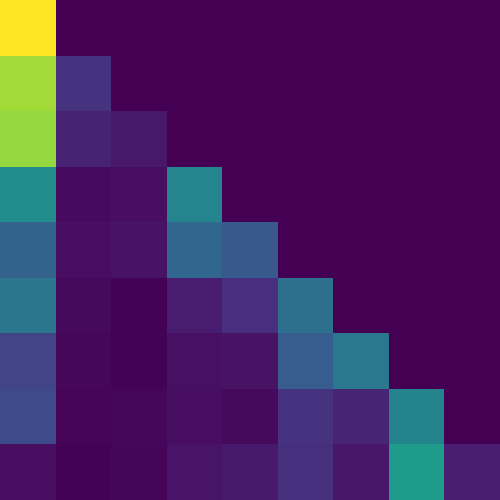

In [15]:
# Cell 11: Heatmaps Only (No Text) - 500x500 & 1000x1000 Looping Versions

import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from IPython.display import Image as IPythonImage, display

# ==========================================
# CONFIGURATION VARIABLES
# ==========================================
# Set even lower for faster animation (50ms = 20 frames per second)
fast_frame_duration_ms = 50
clean_output_dir = "clean-heads"
gif_name_500 = "clean_attention_500x500.gif"
gif_name_1000 = "clean_attention_1000x1000.gif"
# ==========================================

os.makedirs(clean_output_dir, exist_ok=True)

num_layers = len(attentions)
num_heads = attentions[0].shape[1]

print("1. Generating pure heatmaps (no text/axes)...")
for layer_idx in range(num_layers):
    for head_idx in range(num_heads):
        attn = attentions[layer_idx][0, head_idx].detach().cpu().float().numpy()

        # Create a figure
        fig, ax = plt.subplots(figsize=(5, 5))

        # Plot the heatmap without any annotations, colorbars, or labels
        sns.heatmap(
            attn,
            cmap='viridis',
            ax=ax,
            cbar=False,
            xticklabels=False,
            yticklabels=False
        )

        # Completely remove the axis and all borders
        ax.axis('off')

        # Force the plot to fill the entire figure box with zero margins
        plt.subplots_adjust(top=1, bottom=0, right=1, left=0, hspace=0, wspace=0)
        plt.margins(0, 0)

        # Save the frame
        file_name = f"{clean_output_dir}/clean_layer_{layer_idx+1:02d}_head_{head_idx+1:02d}.png"
        plt.savefig(file_name, format='png', dpi=100, bbox_inches='tight', pad_inches=0)

        # Close to save memory
        plt.close(fig)

print(f"2. Resizing frames and merging at {fast_frame_duration_ms}ms per frame...")
image_paths = sorted(glob.glob(f"{clean_output_dir}/clean_layer_*_head_*.png"))

if image_paths:
    frames_500 = []
    frames_1000 = []

    # Use modern Resampling method (fallback for older Pillow versions)
    try:
        resample_method = Image.Resampling.LANCZOS
    except AttributeError:
        resample_method = Image.LANCZOS

    # Open, resize, and store frames
    for img_path in image_paths:
        with Image.open(img_path) as img:
            # Convert to RGB to avoid palette issues
            img = img.convert("RGB")
            # Resize exactly to requested dimensions
            frames_500.append(img.resize((500, 500), resample_method))
            frames_1000.append(img.resize((1000, 1000), resample_method))

    print("3. Saving 500x500 GIF...")
    frames_500[0].save(
        gif_name_500,
        format='GIF',
        append_images=frames_500[1:],
        save_all=True,
        duration=fast_frame_duration_ms,
        loop=0 # 0 guarantees infinite looping
    )

    print("4. Saving 1000x1000 GIF...")
    frames_1000[0].save(
        gif_name_1000,
        format='GIF',
        append_images=frames_1000[1:],
        save_all=True,
        duration=fast_frame_duration_ms,
        loop=0 # 0 guarantees infinite looping
    )

    print("5. Both GIFs generated successfully!")

    # Trigger the download to the user's PC
    try:
        from google.colab import files
        print("6. Downloading both GIFs to your computer...")
        files.download(gif_name_500)
        files.download(gif_name_1000)
    except ImportError:
        print(f"6. Colab not detected. GIFs saved locally at:\n- {os.path.abspath(gif_name_500)}\n- {os.path.abspath(gif_name_1000)}")

    # Show a preview in the notebook (using binary data bypasses the Colab preview freezing bug)
    print("\nPreview (500x500 Version):")
    with open(gif_name_500, "rb") as f:
        display(IPythonImage(data=f.read()))
else:
    print("Error: No images were generated.")